## Preliminary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./FWSL25_matches2.csv')

In [2]:
df.shape

(1658, 89)

In [3]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest
intensity_metrics =['player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']
volume_metrics = ['distance_km','sprint_distance_m','power_plays','energy_kcal','impacts']


In [4]:
df['match_day'] = df['match_day'].str.replace('Wmd', 'MD')

In [5]:
from IPython.display import HTML

def style_table_for_docs(df, hide_index=False):
    styled = (
        df.style
        .set_properties(**{
            'color': 'black',
            'background-color': 'white',
            'border': '1px solid black',
            'text-align': 'center',
            'padding': '2px'  # reduces row height
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')  # also reduce header row height
            ]},
            {'selector': 'td', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')
            ]},
            {'selector': 'table', 'props': [
                ('border', '2px solid black'), 
                ('border-collapse', 'collapse')
            ]}
        ])
    )
    
    if hide_index:
        styled = styled.hide(axis='index')

    return styled


In [6]:
df['total_accelerations'] = df[
	[
		'accelerations_zone_count:_1__2_mss',
		'accelerations_zone_count:_2__3_mss',
		'accelerations_zone_count:_3__4_mss',
		'accelerations_zone_count:_>_4_mss'
	]
].sum(axis=1)

df['total_decelerations'] = df[
	[
		'deceleration_zone_count:_1__2_mss',
		'deceleration_zone_count:_2__3_mss',
		'deceleration_zone_count:_3__4_mss',
		'deceleration_zone_count:_>_4_mss'
	]
].sum(axis=1)


In [7]:
volume_metrics.append('total_accelerations')
volume_metrics.append('total_decelerations')

df['acc_counts_per_min'] = df['total_accelerations'] / df['duration']
df['dec_counts_per_min'] = df['total_decelerations'] / df['duration']

intensity_metrics.append('acc_counts_per_min')
intensity_metrics.append('dec_counts_per_min')

## Summary

In [8]:
table1 = df[['player_load','power_score_wkg','work_ratio']].agg(['sum', 'mean', 'std']).T
style_table_for_docs(table1.round(2))

,sum,mean,std
player_load,599477.840000,361.570000,94.260000
power_score_wkg,19248.830000,11.610000,3.120000
work_ratio,98163.500000,59.210000,17.570000


In [9]:
summary_table_intensity = df[intensity_metrics].agg(['max', 'mean', 'std']).T
style_table_for_docs(summary_table_intensity.round(2))

,max,mean,std
player_load,593.190000,361.570000,94.260000
top_speed_kmh,32.400000,25.620000,2.010000
distance_per_min_mmin,116.960000,74.850000,19.840000
power_score_wkg,18.790000,11.610000,3.120000
work_ratio,101.920000,59.210000,17.570000
max_acceleration_mss,10.000000,5.230000,0.570000
max_deceleration_mss,10.000000,6.440000,0.950000
acc_counts_per_min,5.980000,3.580000,1.010000
dec_counts_per_min,5.970000,3.470000,0.990000


In [10]:
summary_table_volume = df[volume_metrics].agg(['sum','mean', 'std']).T
style_table_for_docs(summary_table_volume.round(2))

,sum,mean,std
distance_km,12258.410000,7.390000,1.970000
sprint_distance_m,710881.850000,428.760000,220.350000
power_plays,62486.000000,37.690000,15.270000
energy_kcal,1212514.630000,731.310000,208.920000
impacts,9398.000000,5.670000,5.580000
total_accelerations,585631.000000,353.220000,99.960000
total_decelerations,568423.000000,342.840000,98.190000


## Data Overview

In [11]:
unique_players_per_club = df.groupby('club_for')['p_name'].nunique().reset_index()
unique_players_per_club.columns = ['club_for', 'unique_players']
style_table_for_docs(unique_players_per_club.sort_values(by='unique_players', ascending=False))

,club_for,unique_players
8,She Maroons Fc,23
2,Kawempe Muslim Lfc,20
1,Kampala Queens Fc,20
0,Amus College Wfc,19
9,Uganda Martyrs Lubaga Wfc,19
4,Makerere University Wfc,17
3,Lady Doves Fc,16
10,Wakiso Hill Wfc,16
6,Rines Ss Wfc,16
5,Olila Hs Wfc,12


In [12]:
players_match_days = df.groupby(['p_name', 'player_club_'])['match_day'].nunique().reset_index()
players_match_days.columns = ['p_name', 'player_club_', 'unique_match_days']
style_table_for_docs(players_match_days.sort_values(by='unique_match_days', ascending=False).head(10))

,p_name,player_club_,unique_match_days
83,Joweria Babirye,She Maroons Fc,20
154,Samalie Nakacwa,Kawempe Muslim Lfc,19
164,Sharifah Nakimera,Kawempe Muslim Lfc,19
31,Comfort Aculu,Uganda Martyrs Lubaga Wfc,18
96,Latifah Nakasi,Uganda Martyrs Lubaga Wfc,18
78,Jolly Kobusinge,Kawempe Muslim Lfc,17
155,Shadia Nabirye,Kawempe Muslim Lfc,17
81,Jovia Nakirya,Rines Ss Wfc,17
46,Esther Namataka,Amus College Wfc,17
3,Agnes Nabukenya,Kawempe Muslim Lfc,17


In [13]:
# Calculate average number of unique players per matchday for each club
players_per_club_day = df.groupby(['club_for', 'match_day'])['p_name'].nunique().reset_index()
avg_players_per_matchday = players_per_club_day.groupby('club_for')['p_name'].mean().reset_index()
avg_players_per_matchday.columns = ['club_for', 'avg_players_per_matchday']
style_table_for_docs(avg_players_per_matchday.sort_values(by='avg_players_per_matchday', ascending=False))

,club_for,avg_players_per_matchday
8,She Maroons Fc,12.050000
4,Makerere University Wfc,11.571429
10,Wakiso Hill Wfc,11.250000
0,Amus College Wfc,11.058824
2,Kawempe Muslim Lfc,11.052632
9,Uganda Martyrs Lubaga Wfc,10.500000
6,Rines Ss Wfc,10.294118
1,Kampala Queens Fc,9.230769
5,Olila Hs Wfc,7.700000
7,She Corporates Fc,6.666667


In [14]:
# Count the number of unique matchdays for each club
unique_matchdays_per_club = df.groupby('club_for')['match_day'].nunique().reset_index()
unique_matchdays_per_club.columns = ['club_for', 'unique_matchdays']
style_table_for_docs(unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False))

,club_for,unique_matchdays
8,She Maroons Fc,20
2,Kawempe Muslim Lfc,19
9,Uganda Martyrs Lubaga Wfc,18
6,Rines Ss Wfc,17
0,Amus College Wfc,17
10,Wakiso Hill Wfc,16
3,Lady Doves Fc,14
4,Makerere University Wfc,14
1,Kampala Queens Fc,13
5,Olila Hs Wfc,10


C:\Users\Travail\AppData\Local\Temp\ipykernel_17980\1451582924.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)


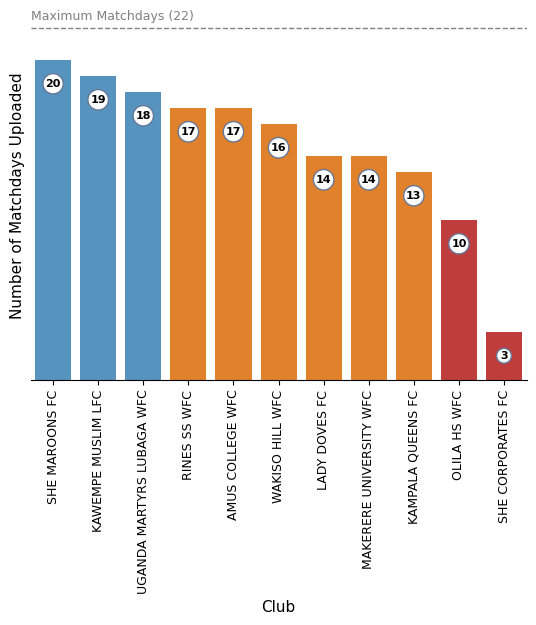

In [15]:
# Sort data
data = unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False)

# Define usage tiers and corresponding colors
def usage_tier_color(val):
    if val >= 18:
        return "#4596cf"  # dark blue for high engagement
    elif val >= 13:
        return '#ff7f0e'  # orange for medium
    else:
        return '#d62728'  # red for low

colors = data['unique_matchdays'].map(usage_tier_color).tolist()

# Create barplot
# plt.figure(figsize=(12,6))
sns.barplot(data=data, x='club_for',hue='club_for', y='unique_matchdays', palette=colors,legend=False)

# Benchmark line at maximum matchdays (22)
plt.axhline(22, color='gray', linestyle='--', linewidth=1)
plt.text(-0.5, 22.5, 'Maximum Matchdays (22)', color='gray', fontsize=9)

# Rotate and uppercase x labels
ax = plt.gca()
ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)

# Title, subtitle, and axis labels
plt.xlabel('Club', fontsize=11)
plt.ylabel('Number of Matchdays Uploaded', fontsize=11)

# Gridlines for y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate values inside bars
for i, value in enumerate(data['unique_matchdays']):
    ax.text(
        i, value - 1.8, str(value),
        ha='center', va='bottom',
        fontsize=8, color='black', fontweight='bold',
        bbox=dict(boxstyle="circle,pad=0.22", edgecolor='#667898', facecolor='white', linewidth=1)
    )
#remove yaxis ticklabels
ax.set_yticklabels([])
ax.set_yticks([])


plt.show()


In [16]:
uploaded_matches = {
    "She Maroons FC": 20,
    "Kawempe Muslim LFC": 22,
    "Uganda Martyrs Lubaga WFC": 18,
    "Rines SS WFC": 22,
    "Amus College WFC": 19,
    "Wakiso Hill WFC": 18,
    "Lady Doves FC": 16,
    "Makerere University WFC": 22,
    "Kampala Queens FC": 17,
    "Olila HS WFC": 13,
    "She Corporates FC": 5,
    "FC Tooro Queens": 0,
    
}

uploaded_matches_df = pd.DataFrame(uploaded_matches.items(), columns=['club_for', 'uploaded_matches'])
uploaded_matches_df['club_for'] = uploaded_matches_df['club_for'].str.title()

uploaded_matches_df=uploaded_matches_df.merge(unique_matchdays_per_club, on='club_for', how='left').sort_values(by='unique_matchdays', ascending=False)
uploaded_matches_df = uploaded_matches_df.rename(columns={
    'uploaded_matches': 'Uploaded Matchdays',
    'unique_matchdays': 'Analysed Matchdays',
})

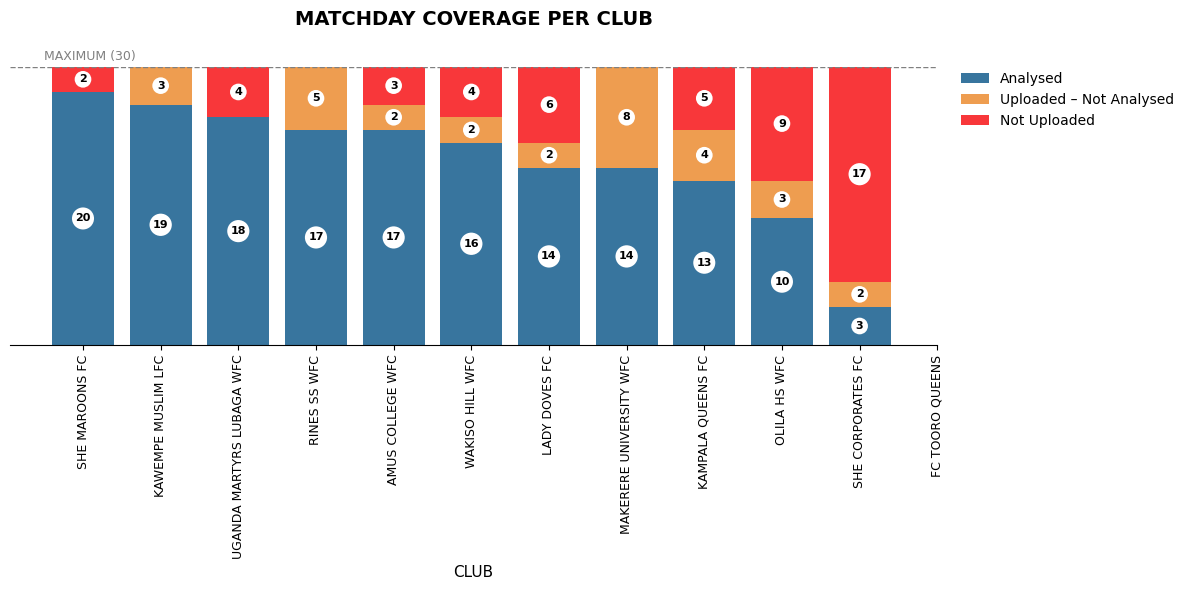

In [17]:

# Prepare DataFrame
uploaded_matches_df_copy = uploaded_matches_df.copy()
uploaded_matches_df_copy['Analysed']      = uploaded_matches_df_copy['Analysed Matchdays']
uploaded_matches_df_copy['Pending']       = uploaded_matches_df_copy['Uploaded Matchdays'] - uploaded_matches_df_copy['Analysed Matchdays']
uploaded_matches_df_copy['not_uploaded']  = 22 - uploaded_matches_df_copy['Uploaded Matchdays']
uploaded_matches_df_copy = uploaded_matches_df_copy.sort_values('Analysed Matchdays', ascending=False)

# Lighter color palette
colors = {
    'Analysed':      "#38759e",  # softer blue
    'Pending':       "#ee9d50",  # softer orange
    'not_uploaded':  "#f8373a"   # softer red
}

fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(uploaded_matches_df_copy))

# Plot segments
ax.bar(x, uploaded_matches_df_copy['Analysed'],
       color=colors['Analysed'],
       label='Analysed')
ax.bar(x, uploaded_matches_df_copy['Pending'],
       bottom=uploaded_matches_df_copy['Analysed'],
       color=colors['Pending'],
       label='Uploaded – Not Analysed')
ax.bar(x, uploaded_matches_df_copy['not_uploaded'],
       bottom=uploaded_matches_df_copy['Analysed'] + uploaded_matches_df_copy['Pending'],
       color=colors['not_uploaded'],
       label='Not Uploaded')

# Benchmark line
ax.axhline(22, color='gray', linestyle='--', linewidth=1)
ax.text(-0.5, 22.5, 'MAXIMUM (30)', color='gray', fontsize=9)

# X labels
ax.set_xticks(x)
ax.set_xticklabels(uploaded_matches_df_copy['club_for'].str.upper(), rotation=90, fontsize=9)

# Clean Y axis
ax.set_yticks([])
ax.set_ylabel('')

# Titles
ax.set_xlabel('CLUB', fontsize=11)
ax.set_title('MATCHDAY COVERAGE PER CLUB', fontsize=14, fontweight='bold',pad='30')

# Gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove spines
sns.despine(ax=ax, left=True, top=True, right=True)

# Annotation helper
def draw_circle_text(xpos, ypos, txt, color):
    ax.text(
        xpos, ypos, str(int(txt)),
        ha='center', va='center', color='black',
        fontsize=8, fontweight='bold',
        bbox=dict(boxstyle="circle,pad=0.3", facecolor='white', edgecolor='none')
    )

# Annotate segments
for idx, row in enumerate(uploaded_matches_df_copy.itertuples()):
    analysed = row.Analysed
    pending  = row.Pending
    notup    = row.not_uploaded

    # Analysed (always)
    if analysed > 0:
        draw_circle_text(idx, analysed / 2, analysed, colors['Analysed'])

    # Pending (always)
    if pending > 1:
        draw_circle_text(idx, analysed + pending / 2, pending, colors['Pending'])

    # not_uploaded (only if > 1)
    if notup > 1:
        ypos = analysed + pending + notup / 2
        draw_circle_text(idx, ypos, notup, colors['not_uploaded'])

# Legend outside
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False
)

plt.tight_layout()
plt.show()


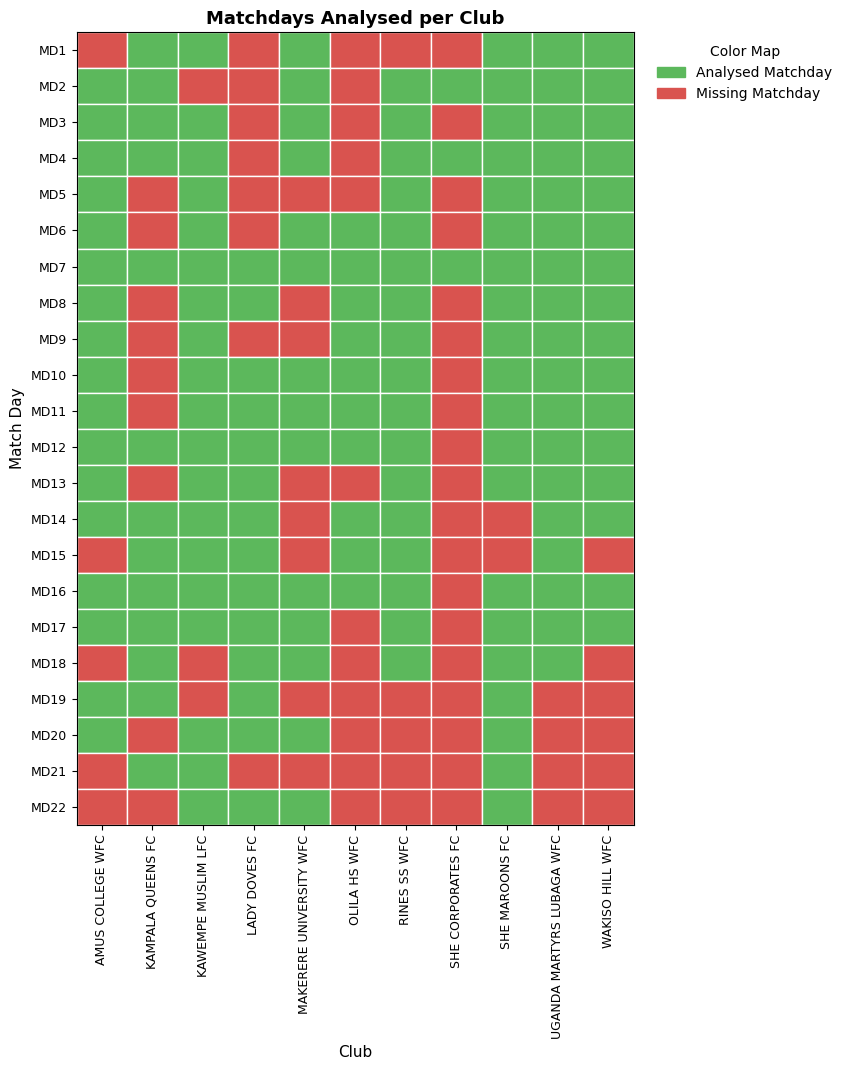

In [18]:
import matplotlib.patches as mpatches

# 1. Get sorted lists of clubs & matchdays
clubs = sorted(df['club_for'].unique())

# Sort matchdays in correct order: MD1, MD2, ..., MD22
matchday_order = [f'MD{i}' for i in range(1, 23)]
matchdays = [md for md in matchday_order if md in df['match_day'].unique()]

# 2. Build a binary grid (1 = analysed, 0 = missing)
grid_data = []
for md in matchdays:
    row = []
    for club in clubs:
        mask = (df['match_day'] == md) & (df['club_for'] == club)
        is_present = 1 if df.loc[mask, 'p_name'].nunique() > 0 else 0
        row.append(is_present)
    grid_data.append(row)

# 3. Convert to DataFrame
grid_df = pd.DataFrame(grid_data, index=matchdays, columns=clubs)

# 4. Define colors
color_map = {1: '#5cb85c', 0: '#d9534f'}  # green = uploaded, red = missing

# 5. Plot
fig, ax = plt.subplots(figsize=(len(clubs)*0.6 + 2, len(matchdays)*0.4 + 2))

for y, md in enumerate(matchdays):
    for x, club in enumerate(clubs):
        val = grid_df.loc[md, club]
        color = color_map[val]
        rect = plt.Rectangle((x, y), 1, 1, facecolor=color, edgecolor='white')
        ax.add_patch(rect)

# 6. Axis Labels
ax.set_xticks(np.arange(len(clubs)) + 0.5)
ax.set_xticklabels([c.upper() for c in clubs], rotation=90, fontsize=9)
ax.set_yticks(np.arange(len(matchdays)) + 0.5)
ax.set_yticklabels([i.upper() for i in matchdays], fontsize=9)

ax.set_xlim(0, len(clubs))
ax.set_ylim(0, len(matchdays))
ax.invert_yaxis()

ax.set_xlabel('Club', fontsize=11)
ax.set_ylabel('Match Day', fontsize=11)
ax.set_title('Matchdays Analysed per Club', fontsize=13, fontweight='bold')

# 7. Legend
handles = [
    mpatches.Patch(color=color_map[1], label='Analysed Matchday'),
    mpatches.Patch(color=color_map[0], label='Missing Matchday')
]
ax.legend(handles=handles, title='Color Map', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

plt.tight_layout()
plt.show()


In [19]:
# Calculate total player entries per matchday across all clubs
total_players_per_matchday = df.groupby('match_day')['p_name'].count().reset_index()
total_players_per_matchday.columns = ['match_day', 'total_player_entries']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'MD{i}' for i in range(1, 23)]
total_players_per_matchday['match_day'] = pd.Categorical(
    total_players_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(total_players_per_matchday.sort_values(by='match_day'))

,match_day,total_player_entries
0,MD1,67
11,MD2,79
15,MD3,91
16,MD4,101
17,MD5,64
18,MD6,94
19,MD7,112
20,MD8,78
21,MD9,74
1,MD10,91


In [20]:
# Count the number of unique clubs that submitted data per matchday
clubs_per_matchday = df.groupby('match_day')['club_for'].nunique().reset_index()
clubs_per_matchday.columns = ['match_day', 'num_clubs']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'MD{i}' for i in range(1, 31)]
clubs_per_matchday['match_day'] = pd.Categorical(
    clubs_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(clubs_per_matchday.sort_values(by='match_day'))


,match_day,num_clubs
0,MD1,6
11,MD2,8
15,MD3,8
16,MD4,9
17,MD5,6
18,MD6,8
19,MD7,11
20,MD8,8
21,MD9,7
1,MD10,9


In [21]:

def plot_line_with_values(data, x_col, y_col, title=None, x_label=None,y_label=None, figsize=(10, 6)):
    # Create figure and axis
    plt.figure(figsize=figsize)
    
    # Plot the line
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)

    
    # Get current axis
    ax = plt.gca()
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set spine and tick colors to light gray
    gray_color = '#808080'
    ax.spines['bottom'].set_color(gray_color)
    ax.spines['left'].set_color(gray_color)
    

    if x_col == 'match_day':
        # Ensure match_day is ordered as per matchday_order
        data[x_col] = pd.Categorical(data[x_col], categories=matchday_order, ordered=True)
        data_sorted = data.sort_values(by=x_col)
        xticklabels = [str(Wmd).replace('Wmd', 'Wmd ') for Wmd in data_sorted[x_col]]
        ax.set_xticks(range(len(data_sorted[x_col])))
        ax.set_xticklabels(xticklabels, rotation=90)
        # Re-plot with sorted data to ensure correct order
        
        sns.lineplot(data=data_sorted, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)
        
    # Add value labels above each point
    for i, (x, y) in enumerate(zip(data[x_col], data[y_col])):
        ax.annotate(
            f'{y}', 
            (x, y),
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center',
            fontsize=8,
            bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#FE912A', facecolor='white', linewidth=1)
        )
    
    # Set title
    if title is None:
        title = f'{y_col} vs {x_col}'
    plt.title(title)

    # #start the y-axis at 0
    # ax.set_ylim(bottom=2,top=14)  # Adjust the top limit as needed
    

    # Set labels
    if x_label is None:
        x_label = x_col.replace('_', ' ').title()
    plt.xlabel(x_label)
    if y_label is None:
        y_label = y_col.replace('_', ' ').title()
    plt.ylabel(y_label)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, color='#E0DCDD', alpha=0.7)
    # Adjust layout
    plt.tight_layout()
    
    return ax

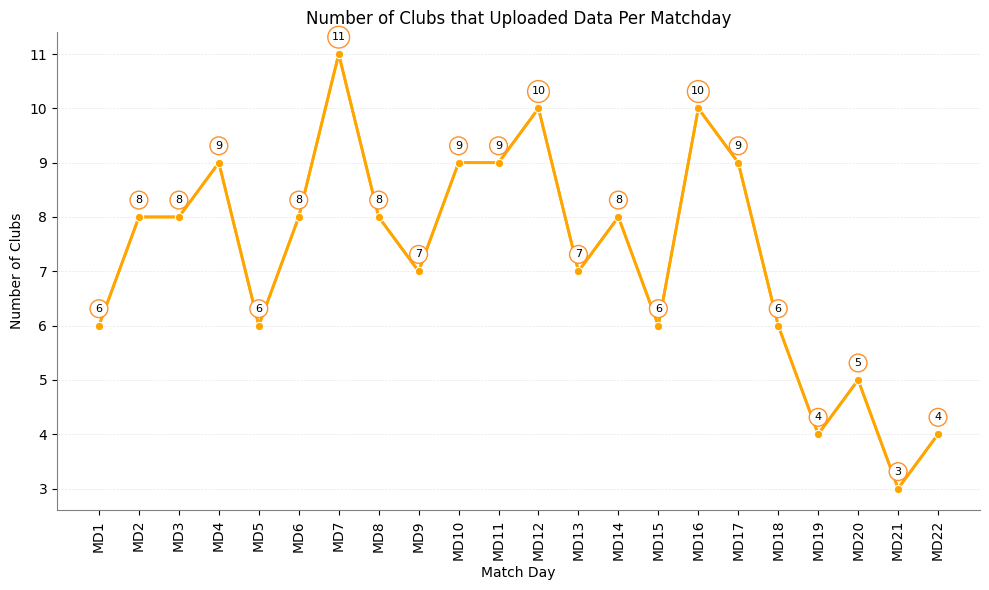

In [22]:
plot_line_with_values(clubs_per_matchday, 'match_day', 'num_clubs', title='Number of Clubs that Uploaded Data Per Matchday',x_label='Match Day', y_label='Number of Clubs');

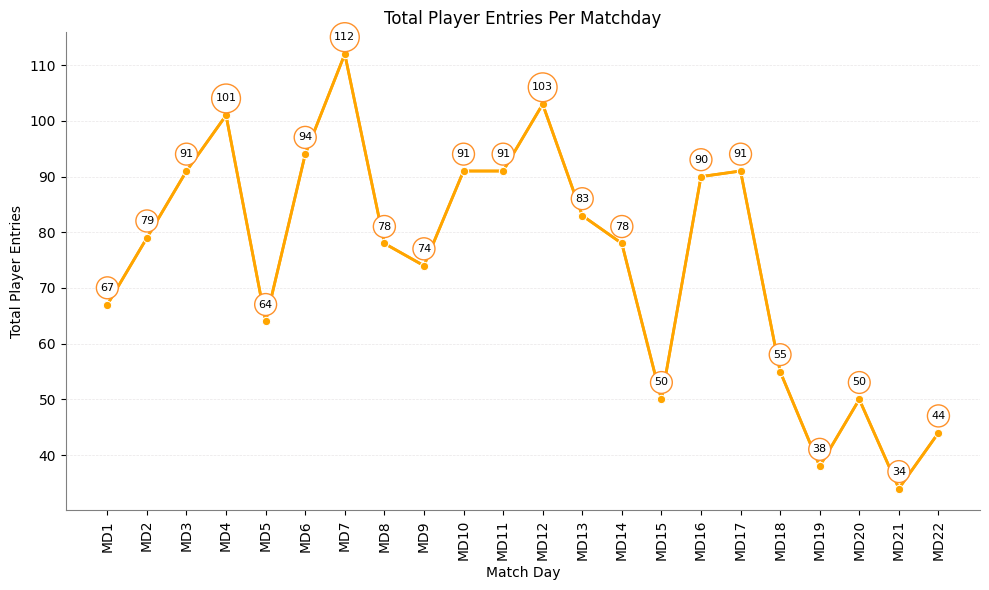

In [23]:
plot_line_with_values(total_players_per_matchday, 'match_day', 'total_player_entries', title='Total Player Entries Per Matchday', x_label='Match Day', y_label='Total Player Entries');

In [24]:
# Count number and percentage of entries based on 'location'
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,location,count,percentage
0,Home,875,52.774427
1,Away,783,47.225573


In [25]:
# Count number and percentage of entries based on 'result'
location_counts = df['result'].value_counts().reset_index()
location_counts.columns = ['result', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,result,count,percentage
0,Win,612,36.911942
1,Draw,580,34.981906
2,Loss,466,28.106152


In [26]:
# Calculate Win-Draw-Loss counts for each club using unique match days
matchday_results = df.groupby(['club_for', 'match_day'])['result'].first().reset_index()
wld_counts = matchday_results.groupby(['club_for', 'result']).size().unstack(fill_value=0)
wld_counts = wld_counts[['Win', 'Draw', 'Loss']]  # Ensure order if all present

style_table_for_docs(wld_counts.sort_values(by='Win', ascending=False))


result,Win,Draw,Loss
club_for,,,
Kawempe Muslim Lfc,9,6,4
Amus College Wfc,8,7,2
Kampala Queens Fc,8,5,0
Lady Doves Fc,7,2,5
She Maroons Fc,7,8,5
Rines Ss Wfc,6,4,7
Makerere University Wfc,6,6,2
Uganda Martyrs Lubaga Wfc,5,6,7
Olila Hs Wfc,3,5,2


### Max Metrics

In [27]:
speed_table = df[['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']].agg(['max', 'mean', 'std']).T
style_table_for_docs(speed_table)

,max,mean,std
top_speed_kmh,32.400300,25.624851,2.013774
distance_per_min_mmin,116.958686,74.848353,19.835923
max_acceleration_mss,10.000000,5.226480,0.572805
max_deceleration_mss,10.000000,6.437293,0.952649


In [28]:
distance_speed_zones = ['distance_in_speed_zone_1_km', 'distance_in_speed_zone_2_km', 'distance_in_speed_zone_3_km','distance_in_speed_zone_4_km','distance_in_speed_zone_5_km']
for i in distance_speed_zones:
    df[i] = df[i] * 1000  # Convert from km to m

speed_zone_dist= df[distance_speed_zones].agg(['sum','max', 'mean', 'std']).T.round(2)
style_table_for_docs(speed_zone_dist)

,sum,max,mean,std
distance_in_speed_zone_1_km,1602464.400000,1872.200000,966.500000,270.340000
distance_in_speed_zone_2_km,6626349.800000,6062.300000,3996.590000,1085.770000
distance_in_speed_zone_3_km,3318721.300000,4494.400000,2001.640000,734.570000
distance_in_speed_zone_4_km,674312.700000,1225.000000,406.700000,200.620000
distance_in_speed_zone_5_km,36563.700000,295.300000,22.050000,32.900000


## Analysis

### Club Comparison

In [29]:
club_metrics_mean = (
    df.groupby(['club_for', 'match_day'],observed=False)[volume_metrics+intensity_metrics].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_distance_km', ascending=False)
    .reset_index()
)
style_table_for_docs(club_metrics_mean.round(2))


,club_for,avg_distance_km,avg_sprint_distance_m,avg_power_plays,avg_energy_kcal,avg_impacts,avg_total_accelerations,avg_total_decelerations,avg_player_load,avg_top_speed_kmh,avg_distance_per_min_mmin,avg_power_score_wkg,avg_work_ratio,avg_max_acceleration_mss,avg_max_deceleration_mss,avg_acc_counts_per_min,avg_dec_counts_per_min
0,Olila Hs Wfc,8.470000,496.960000,42.320000,825.220000,3.820000,386.250000,374.510000,384.610000,25.980000,86.030000,13.300000,69.730000,5.190000,6.360000,3.920000,3.800000
1,Lady Doves Fc,8.030000,504.100000,42.240000,737.090000,6.430000,367.140000,359.150000,393.470000,26.000000,82.500000,12.670000,63.360000,5.250000,6.630000,3.770000,3.690000
2,Amus College Wfc,7.760000,510.470000,42.390000,762.680000,7.100000,366.620000,356.270000,382.860000,26.050000,76.630000,11.940000,61.830000,5.310000,6.590000,3.620000,3.520000
3,Uganda Martyrs Lubaga Wfc,7.650000,417.510000,36.380000,724.850000,6.060000,360.140000,346.840000,379.080000,25.570000,75.400000,11.610000,59.130000,5.050000,6.610000,3.550000,3.420000
4,She Corporates Fc,7.630000,382.680000,36.820000,648.700000,2.470000,348.910000,339.010000,347.580000,24.850000,77.550000,12.000000,59.620000,5.160000,6.660000,3.550000,3.450000
5,Kampala Queens Fc,7.590000,433.260000,39.440000,738.430000,6.090000,376.660000,364.710000,384.800000,26.350000,77.830000,12.110000,60.630000,5.350000,6.480000,3.860000,3.740000
6,Kawempe Muslim Lfc,7.460000,453.750000,39.560000,734.130000,4.120000,349.940000,339.700000,349.010000,25.450000,77.560000,12.060000,61.830000,5.420000,6.360000,3.640000,3.530000
7,Rines Ss Wfc,7.450000,399.230000,35.390000,748.150000,5.010000,360.780000,351.460000,362.340000,25.460000,75.920000,11.690000,59.910000,5.230000,6.590000,3.680000,3.580000
8,Makerere University Wfc,7.220000,369.380000,35.040000,686.130000,5.960000,338.900000,331.150000,349.210000,25.050000,70.690000,10.950000,55.100000,5.150000,6.260000,3.310000,3.240000
9,Wakiso Hill Wfc,7.060000,338.150000,32.440000,642.410000,7.060000,365.790000,352.330000,360.580000,25.010000,71.350000,11.090000,56.830000,5.110000,6.160000,3.690000,3.560000


In [30]:
team_avg_dist_per_match = (
    df
    .groupby(['club_for', 'match_day'], observed=False)['distance_km']
    .sum()  # Total team distance on a match day
    .groupby('club_for')
    .mean()  # Average total team distance per match across all match days
    .reset_index(name='avg_team_distance_per_match_km')
    .sort_values(by='avg_team_distance_per_match_km', ascending=False)
)
style_table_for_docs(team_avg_dist_per_match)

,club_for,avg_team_distance_per_match_km
0,Amus College Wfc,89.607006
4,Makerere University Wfc,83.084564
2,Kawempe Muslim Lfc,81.915958
8,She Maroons Fc,80.710645
9,Uganda Martyrs Lubaga Wfc,80.133294
10,Wakiso Hill Wfc,78.944800
6,Rines Ss Wfc,75.913506
1,Kampala Queens Fc,69.374685
5,Olila Hs Wfc,64.800630
7,She Corporates Fc,51.422333


In [31]:
club_intensity_max = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin']]
    .max()
    .rename(columns=lambda x: f'max_{x}')
    .sort_values(by='max_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_max.round(2))

,club_for,max_top_speed_kmh,max_distance_per_min_mmin
0,Kampala Queens Fc,32.400000,105.500000
1,Kawempe Muslim Lfc,31.170000,115.150000
2,She Maroons Fc,30.610000,116.960000
3,Amus College Wfc,30.460000,111.920000
4,Uganda Martyrs Lubaga Wfc,30.450000,107.170000
5,Lady Doves Fc,30.410000,111.860000
6,Rines Ss Wfc,30.340000,113.500000
7,Olila Hs Wfc,29.860000,111.070000
8,Wakiso Hill Wfc,29.570000,105.420000
9,Makerere University Wfc,29.150000,106.040000


In [32]:
club_intensity_avg = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin']]
    .mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_avg.round(2))

,club_for,avg_top_speed_kmh,avg_distance_per_min_mmin
0,Kampala Queens Fc,26.340000,76.940000
1,Amus College Wfc,26.060000,76.570000
2,Lady Doves Fc,25.990000,82.530000
3,She Maroons Fc,25.920000,69.470000
4,Olila Hs Wfc,25.910000,85.830000
5,Uganda Martyrs Lubaga Wfc,25.570000,75.310000
6,Kawempe Muslim Lfc,25.460000,77.050000
7,Rines Ss Wfc,25.410000,75.340000
8,Wakiso Hill Wfc,25.050000,70.730000
9,Makerere University Wfc,25.020000,70.060000


### Metric High Scores

In [33]:
# For each metric in volume_metrics, find the player with the highest value, the value, and the club
top_players = []
for metric in volume_metrics +intensity_metrics:
    idx = df[metric].idxmax()
    row = df.loc[idx]
    top_players.append({
        'metric': metric,
        'player': row['p_name'],
        'club': row['club_for'],
        'value': row[metric],
        'match day': row['match_day']
    })

top_players_df = pd.DataFrame(top_players)
style_table_for_docs(top_players_df)

,metric,player,club,value,match day
0,distance_km,Irene Nantege,Lady Doves Fc,11.261000,MD11
1,sprint_distance_m,Jovia Nakagolo,Kawempe Muslim Lfc,1396.526000,MD20
2,power_plays,Joyce Kainza,Amus College Wfc,97.000000,MD9
3,energy_kcal,Jackeline Adong,She Maroons Fc,1334.901400,MD20
4,impacts,Yasmeen Nalukwago,Rines Ss Wfc,44.000000,MD17
5,total_accelerations,Immaculate Nakanjako,Uganda Martyrs Lubaga Wfc,601.000000,MD2
6,total_decelerations,Phionah Arach,Rines Ss Wfc,586.000000,MD17
7,player_load,Catherine Namataka,Amus College Wfc,593.191200,MD13
8,top_speed_kmh,Muduwa Peace,Kampala Queens Fc,32.400300,MD17
9,distance_per_min_mmin,Jackeline Adong,She Maroons Fc,116.958686,MD20


### Comparison by Position Group

In [34]:
# Calculate average volume metrics by general position
avg_volume_by_position = df.groupby('general_position')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_position)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
general_position,,,,,,,
Defenders,7.670000,429.200000,37.210000,755.240000,6.190000,369.350000,357.060000
Forwards,6.800000,487.930000,39.570000,671.370000,4.880000,311.780000,302.430000
Midfielders,7.680000,362.340000,36.240000,765.900000,5.840000,377.660000,368.700000


In [35]:
# Calculate average intensity metrics by general position
avg_intensity_by_position = df.groupby('general_position')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_position)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
general_position,,,,,
Defenders,373.319287,11.997689,60.522370,3.738835,3.613820
Forwards,330.726552,10.719319,53.438918,3.149409,3.055459
Midfielders,380.108835,12.079581,63.855658,3.834374,3.743897


In [36]:
# Calculate max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].max().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defenders,30.340000,112.930000,5.710000,5.520000
Forwards,32.400000,113.500000,5.960000,5.740000
Midfielders,30.410000,116.960000,5.980000,5.970000


In [37]:
# Calculate mean max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].mean().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defenders,25.810000,77.650000,3.740000,3.610000
Forwards,26.450000,68.680000,3.150000,3.060000
Midfielders,24.460000,77.950000,3.830000,3.740000


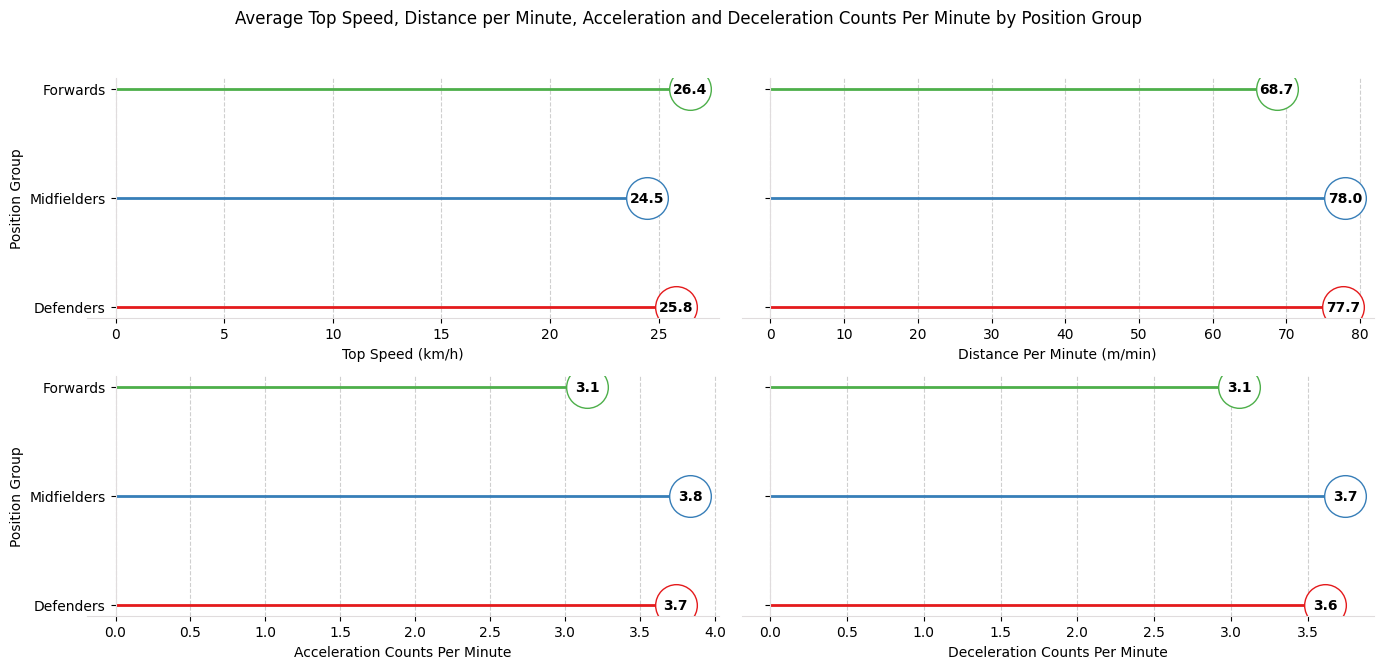

In [38]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('top_speed_kmh', 'Top Speed (km/h)'),
    ('distance_per_min_mmin', 'Distance Per Minute (m/min)'),
    ('acc_counts_per_min', 'Acceleration Counts Per Minute'),
    ('dec_counts_per_min', 'Deceleration Counts Per Minute')
]

# Define the order of position groups
position_order = ['Defenders', 'Midfielders', 'Forwards']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 30

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'top_speed_kmh':
            text_val = f'{val:.1f}'
        elif metric == 'distance_per_min_mmin':
            text_val = f'{val:.1f}'
        elif metric == 'acc_counts_per_min':
            text_val = f'{val:.1f}'
        else:
            text_val = f'{val:.1f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=10, color='black', fontweight='bold')

    yticklabels = [f"{pos}" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Top Speed, Distance per Minute, Acceleration and Deceleration Counts Per Minute by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


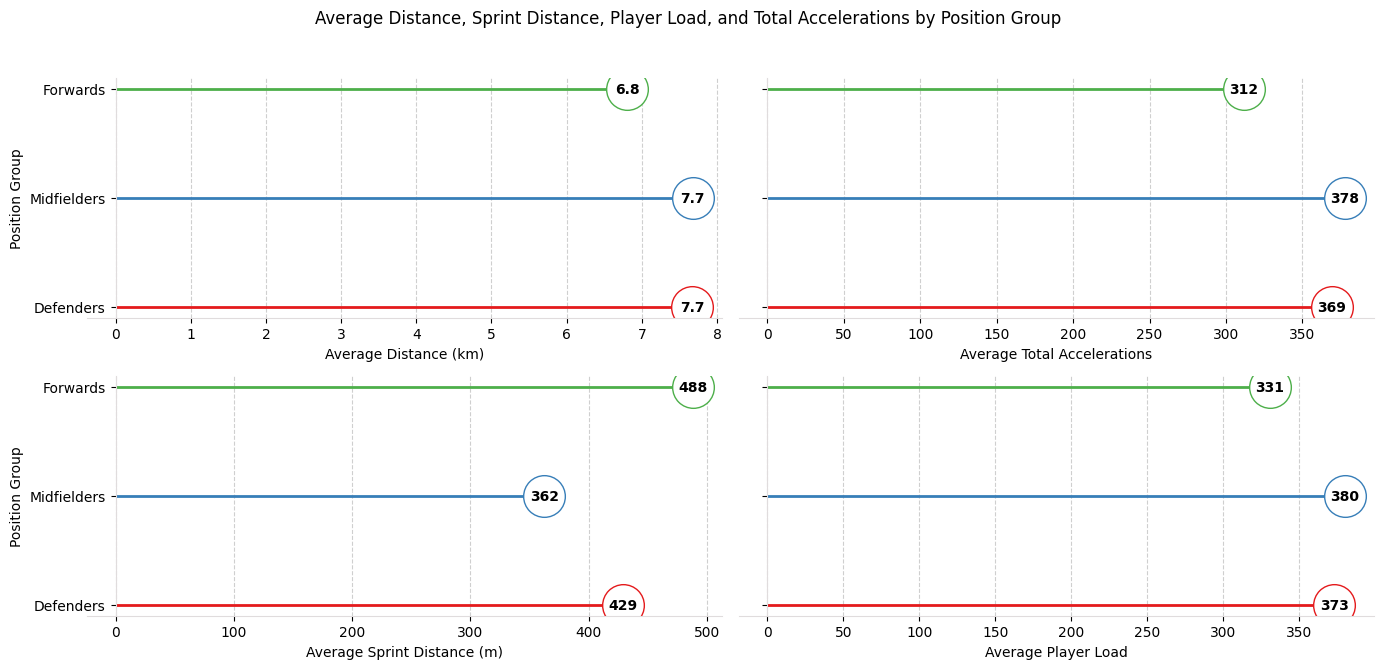

In [39]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('distance_km', 'Average Distance (km)'),
    ('total_accelerations', 'Average Total Accelerations'),
    ('sprint_distance_m', 'Average Sprint Distance (m)'),
    ('player_load', 'Average Player Load')
]

# Define the order of position groups
position_order = ['Defenders', 'Midfielders', 'Forwards']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 30

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'distance_km':
            text_val = f'{val:.1f}'
        elif metric == 'sprint_distance_m':
            text_val = f'{val:.0f}'
        elif metric == 'player_load':
            text_val = f'{val:.0f}'
        else:
            text_val = f'{val:.0f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=10, color='black', fontweight='bold')

    yticklabels = [f"{pos}" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Distance, Sprint Distance, Player Load, and Total Accelerations by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Comparison by Location

In [40]:
# Calculate average volume metrics by location
avg_volume_by_location = df.groupby('location')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_location)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
location,,,,,,,
Away,7.490000,428.280000,37.970000,737.510000,5.670000,358.540000,347.690000
Home,7.310000,429.190000,37.440000,725.760000,5.670000,348.450000,338.490000


In [41]:
# Calculate average intensity metrics by location
avg_intensity_by_location = df.groupby('location')[[i for i in intensity_metrics ]].mean()
style_table_for_docs(avg_intensity_by_location)

,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
location,,,,,,,,,
Away,365.330626,25.601661,75.813402,11.765009,60.094710,5.253208,6.453951,3.630468,3.520680
Home,358.198812,25.645603,73.984771,11.470658,58.410682,5.202563,6.422387,3.528500,3.427764


In [42]:
# Calculate max metrics by location
avg_intensity_by_location_ = df.groupby('location')[['top_speed_kmh','distance_per_min_mmin']].max().round(2)
style_table_for_docs(avg_intensity_by_location_)

,top_speed_kmh,distance_per_min_mmin
location,,
Away,32.400000,115.150000
Home,31.170000,116.960000


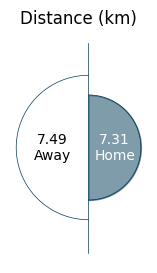

In [43]:
def plot_home_away_top_speed(avg_volume_by_location, color='#003b59', min_radius=0.8, max_radius=1.1):
    """
    Plot a semicircle comparison of top speed (km/h) for Home vs Away using avg_volume_by_location DataFrame.
    """
    home_speed = avg_volume_by_location.loc['Home', 'distance_km']
    away_speed = avg_volume_by_location.loc['Away', 'distance_km']

    speeds = np.array([home_speed, away_speed])
    norm_radii = min_radius + (speeds - speeds.min()) / (speeds.max() - speeds.min()) * (max_radius - min_radius)
    home_radius, away_radius = norm_radii

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_aspect('equal')
    ax.axis('off')

    # Draw right (Home) semicircle
    theta_home = np.linspace(-np.pi/2, np.pi/2, 100)
    x_home = home_radius * np.cos(theta_home)
    y_home = home_radius * np.sin(theta_home)
    ax.plot(x_home, y_home, color=color, linewidth=0.5)
    if home_radius < away_radius:
        ax.fill_betweenx(y_home, 0, x_home, color=color, alpha=0.5)

    # Draw left (Away) semicircle
    theta_away = np.linspace(np.pi/2, 3*np.pi/2, 100)
    x_away = away_radius * np.cos(theta_away)
    y_away = away_radius * np.sin(theta_away)
    ax.plot(x_away, y_away, color=color, linewidth=0.5)
    if away_radius < home_radius:
        ax.fill_betweenx(y_away, x_away, 0, color=color, alpha=0.5)

    # Draw the separating line
    ax.plot([0, 0], [-max(home_radius+0.5, away_radius+0.5), max(home_radius+0.5, away_radius+0.5)], color=color, linewidth=0.5, zorder=3)

    # Place values inside semicircles
    ax.text(home_radius * 0.5, 0, f"{home_speed:.2f}\nHome", ha='center', va='center', fontsize=10, color='#fff', fontweight='normal')
    ax.text(-away_radius * 0.5, 0, f"{away_speed:.2f}\nAway", ha='center', va='center', fontsize=10, color='#000', fontweight='normal')

    plt.title('Distance (km)', fontsize=12)
    plt.show()
plot_home_away_top_speed(avg_volume_by_location)

### Metric Distribution 

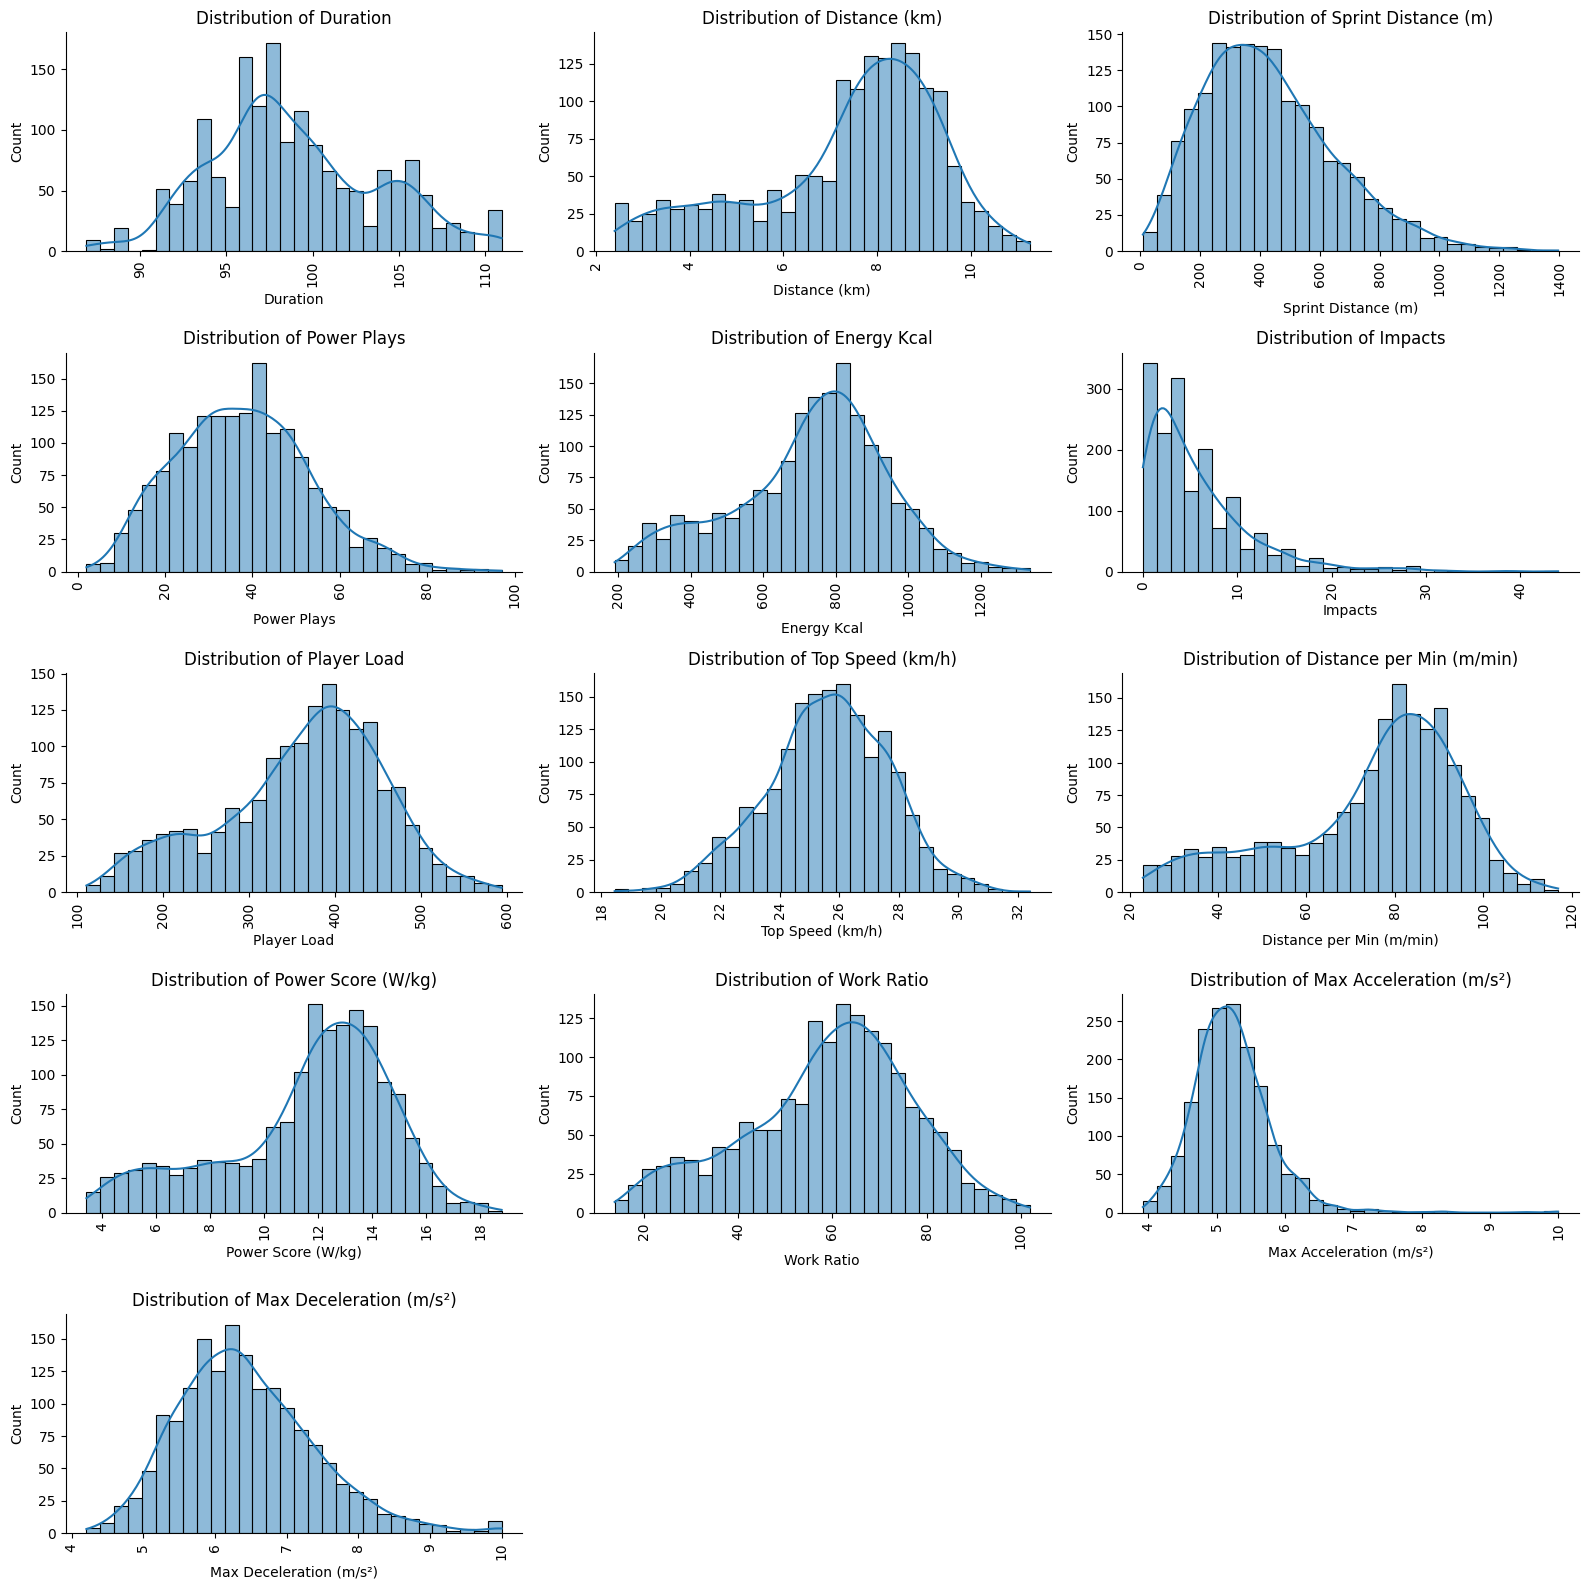

In [44]:
plt.figure(figsize=(16, 16))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    # Format title and x-label: replace _ with space, capitalize, add units if present
    label = col.replace('_', ' ').title()
    # Add units for specific columns
    if col == 'distance_km':
        label = 'Distance (km)'
    elif col == 'sprint_distance_m':
        label = 'Sprint Distance (m)'
    elif col == 'top_speed_kmh':
        label = 'Top Speed (km/h)'
    elif col == 'distance_per_min_mmin':
        label = 'Distance per Min (m/min)'
    elif col == 'power_score_wkg':
        label = 'Power Score (W/kg)'
    elif col == 'max_acceleration_mss':
        label = 'Max Acceleration (m/s²)'
    elif col == 'max_deceleration_mss':
        label = 'Max Deceleration (m/s²)'
    elif col == 'acc_counts_per_min':
        label = 'Acc. Counts per Min'
    elif col == 'dec_counts_per_min':
        label = 'Dec. Counts per Min'
    
    plt.title(f'Distribution of {label}')
    plt.xlabel(label)
    plt.xticks(rotation=90)
    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



## Trend Analysis

In [45]:
avg_volume_per_matchday = df.groupby('match_day')[volume_metrics + intensity_metrics].mean().reset_index()
# Ensure 'match_day' is a categorical variable with the correct order
avg_volume_per_matchday['match_day'] = pd.Categorical(
    avg_volume_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
avg_volume_per_matchday = avg_volume_per_matchday.sort_values(by='match_day').round(2)
style_table_for_docs(avg_volume_per_matchday)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,MD1,6.960000,348.880000,32.300000,687.380000,5.580000,346.910000,335.010000,343.950000,25.130000,71.050000,11.010000,56.850000,5.120000,6.150000,3.540000,3.420000
11,MD2,7.100000,392.410000,34.890000,699.780000,5.380000,346.810000,335.230000,352.280000,25.410000,68.980000,10.730000,54.960000,5.150000,6.420000,3.380000,3.270000
15,MD3,7.460000,434.050000,39.840000,743.090000,6.510000,371.420000,360.620000,369.990000,25.440000,76.800000,11.890000,61.690000,5.270000,6.590000,3.820000,3.710000
16,MD4,7.260000,429.240000,36.580000,716.330000,5.680000,346.610000,337.690000,351.870000,25.520000,74.070000,11.500000,59.140000,5.280000,6.510000,3.540000,3.450000
17,MD5,7.270000,411.030000,37.660000,719.440000,6.080000,360.750000,349.190000,359.030000,25.680000,73.030000,11.240000,56.810000,5.550000,6.430000,3.620000,3.500000
18,MD6,7.100000,395.570000,35.940000,699.520000,4.070000,340.930000,328.380000,342.880000,25.420000,72.890000,11.290000,58.040000,5.140000,6.290000,3.500000,3.370000
19,MD7,7.470000,430.710000,37.410000,731.980000,6.190000,358.620000,346.770000,362.860000,25.690000,75.920000,11.730000,59.630000,5.230000,6.500000,3.650000,3.530000
20,MD8,7.430000,413.820000,37.650000,729.290000,5.000000,370.370000,360.940000,366.350000,25.110000,75.610000,11.780000,60.570000,4.960000,6.210000,3.770000,3.670000
21,MD9,7.230000,436.330000,38.220000,725.830000,5.340000,337.720000,329.120000,342.340000,25.940000,76.860000,11.910000,60.890000,5.160000,6.600000,3.590000,3.500000
1,MD10,7.390000,395.000000,35.590000,729.500000,5.330000,352.130000,342.890000,355.180000,25.450000,74.010000,11.460000,58.130000,5.200000,6.480000,3.520000,3.430000


In [46]:
# Sort by match_day using the correct order
df['match_day'] = pd.Categorical(df['match_day'], categories=matchday_order, ordered=True)
df_sorted = df.sort_values('match_day')

# Compute rolling mean for each metric per match day
rolling_avg = (
    df_sorted.groupby('match_day', observed=True)[volume_metrics + intensity_metrics]
    .mean()
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index()
)

rolling_avg['match_day'] = pd.Categorical(rolling_avg['match_day'], categories=matchday_order, ordered=True)
rolling_avg = rolling_avg.sort_values(by='match_day').round(2)
style_table_for_docs(rolling_avg)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,MD1,6.960000,348.880000,32.300000,687.380000,5.580000,346.910000,335.010000,343.950000,25.130000,71.050000,11.010000,56.850000,5.120000,6.150000,3.540000,3.420000
1,MD2,7.030000,370.640000,33.590000,693.580000,5.480000,346.860000,335.120000,348.120000,25.270000,70.020000,10.870000,55.900000,5.140000,6.280000,3.460000,3.340000
2,MD3,7.180000,391.780000,35.670000,710.090000,5.820000,355.050000,343.620000,355.410000,25.330000,72.280000,11.210000,57.830000,5.180000,6.390000,3.580000,3.460000
3,MD4,7.270000,418.560000,37.100000,719.730000,5.860000,354.950000,344.510000,358.050000,25.460000,73.280000,11.370000,58.600000,5.230000,6.510000,3.580000,3.470000
4,MD5,7.330000,424.770000,38.030000,726.290000,6.090000,359.590000,349.170000,360.300000,25.550000,74.640000,11.540000,59.220000,5.370000,6.510000,3.660000,3.550000
5,MD6,7.210000,411.940000,36.730000,711.760000,5.280000,349.430000,338.420000,351.260000,25.540000,73.330000,11.350000,58.000000,5.320000,6.410000,3.550000,3.440000
6,MD7,7.280000,412.430000,37.000000,716.980000,5.450000,353.430000,341.450000,354.920000,25.600000,73.950000,11.420000,58.160000,5.310000,6.410000,3.590000,3.470000
7,MD8,7.330000,413.370000,37.000000,720.260000,5.090000,356.640000,345.360000,357.360000,25.410000,74.810000,11.600000,59.410000,5.110000,6.330000,3.640000,3.520000
8,MD9,7.380000,426.950000,37.760000,729.030000,5.510000,355.570000,345.610000,357.180000,25.580000,76.130000,11.810000,60.360000,5.120000,6.440000,3.670000,3.570000
9,MD10,7.350000,415.050000,37.150000,728.210000,5.220000,353.410000,344.320000,354.620000,25.500000,75.490000,11.720000,59.860000,5.110000,6.430000,3.630000,3.530000


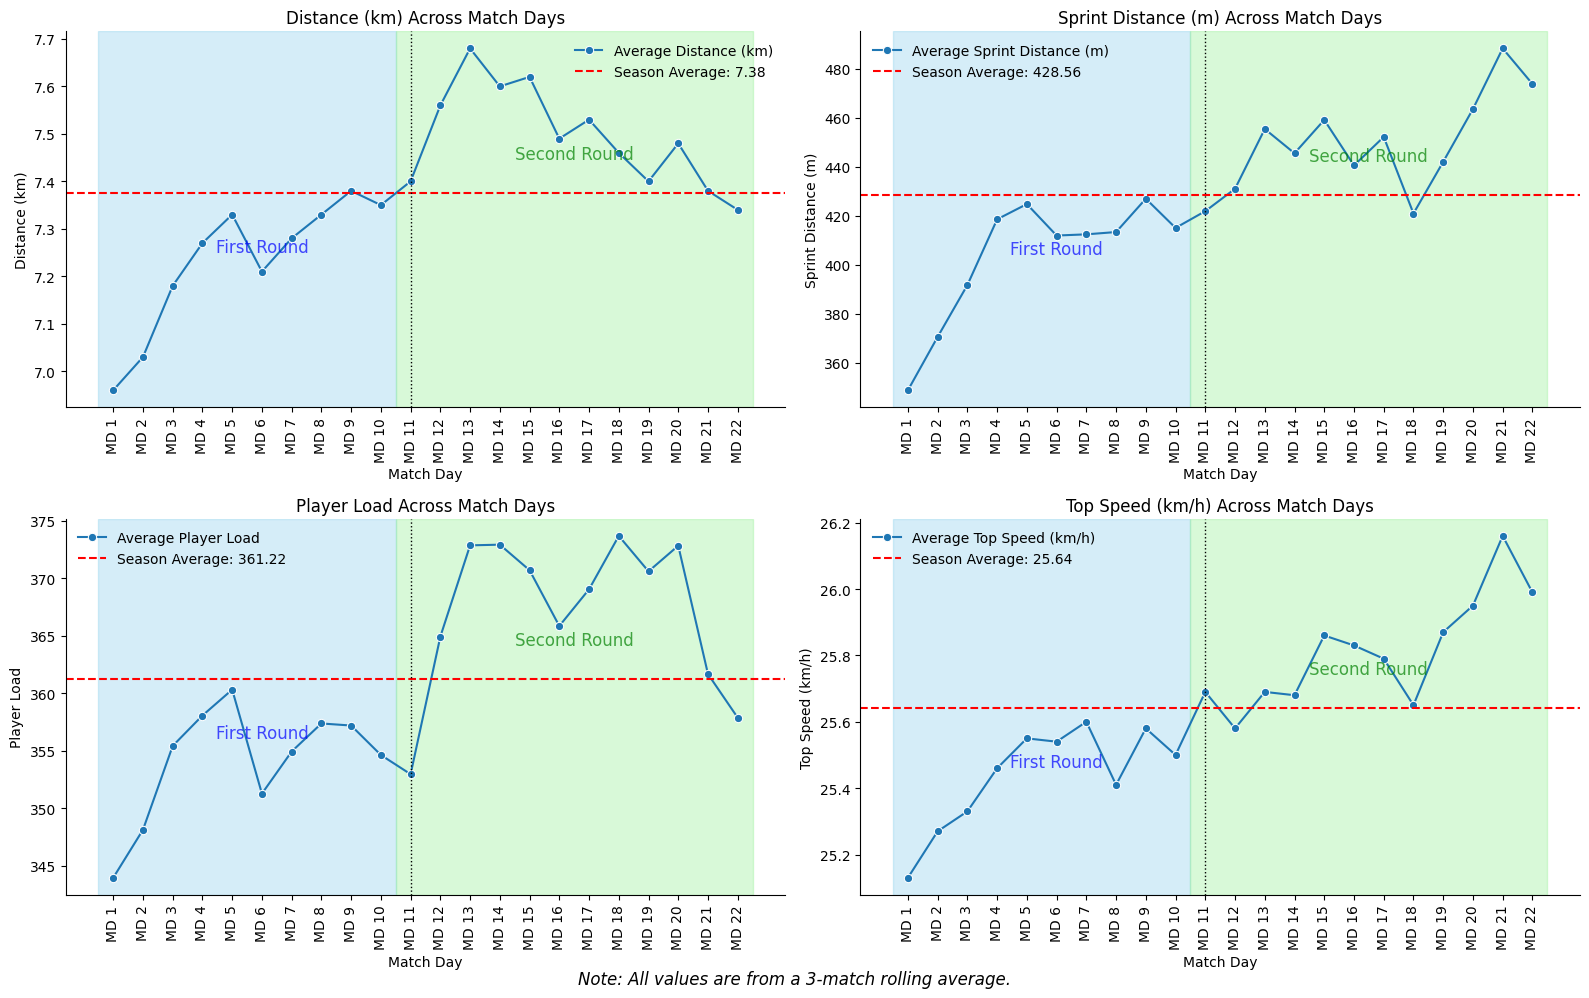

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [
    ('distance_km', 'Distance (km)'),
    ('sprint_distance_m', 'Sprint Distance (m)'),
    ('player_load', 'Player Load'),
    ('top_speed_kmh', 'Top Speed (km/h)')
]

# Get valid match days (non-NaN)
valid_matchdays = rolling_avg['match_day'].dropna().tolist()
MD11_idx = valid_matchdays.index('MD11') if 'MD11' in valid_matchdays else None
last_idx = len(valid_matchdays) - 1

for ax, (col, label) in zip(axes.flatten(), metrics):
    sns.lineplot(
        data=rolling_avg,
        x='match_day',
        y=col,
        marker='o',
        ax=ax,
        label=f'Average {label}'
    )
    avg_value = rolling_avg[col].mean()
    ax.axhline(avg_value, color='red', linestyle='--', label=f'Season Average: {avg_value:.2f}')
    # Draw vertical line at MD11
    ax.axvline(MD11_idx, color='black', linestyle=':', linewidth=1)
    # Shade area before MD11 (First Round)
    ax.axvspan(-0.5, MD11_idx - 0.5, color='skyblue', alpha=0.35)
    # Shade area from MD11 to last matchday (Second Round)
    ax.axvspan(MD11_idx - 0.5, last_idx + 0.5, color='lightgreen', alpha=0.35)
    xticklabels = [str(Wmd).replace('MD', 'MD ') for Wmd in valid_matchdays]
    ax.set_xticks(range(len(valid_matchdays)))
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_title(f'{label} Across Match Days')
    ax.set_xlabel('Match Day')
    ax.set_ylabel(label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend = ax.legend(frameon=False)
    ymin, ymax = ax.get_ylim()
    ax.text(MD11_idx/2, avg_value - (ymax-ymin)*0.12, 'First Round', color='blue', fontsize=12, ha='center', va='top', alpha=0.7)
    ax.text(MD11_idx + (last_idx-MD11_idx)/2, avg_value + (ymax-ymin)*0.08, 'Second Round', color='green', fontsize=12, ha='center', va='bottom', alpha=0.7)

plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.figtext(0.5, 0.01, "Note: All values are from a 3-match rolling average.", ha='center', fontsize=12, style='italic')
plt.show()


## Correlation Analysis

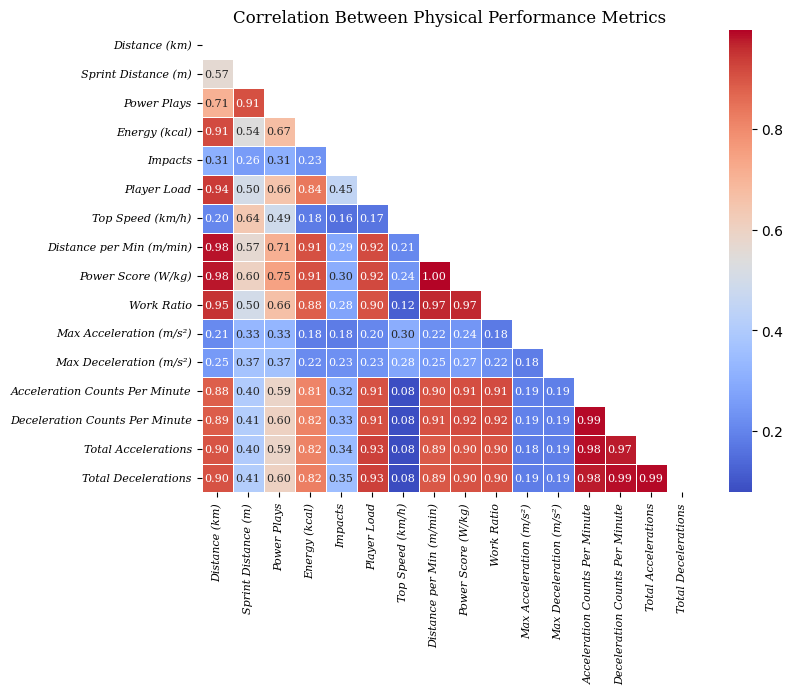

In [48]:
cols_to_corr = [col for col in num_cols if col != 'duration']
cols_to_corr.extend(['acc_counts_per_min','dec_counts_per_min','total_accelerations','total_decelerations'])
corr = df[cols_to_corr].corr(method='pearson')

# Mapping for pretty axis labels
pretty_labels = {
    'distance_km': 'Distance (km)',
    'sprint_distance_m': 'Sprint Distance (m)',
    'power_plays': 'Power Plays',
    'energy_kcal': 'Energy (kcal)',
    'impacts': 'Impacts',
    'player_load': 'Player Load',
    'top_speed_kmh': 'Top Speed (km/h)',
    'distance_per_min_mmin': 'Distance per Min (m/min)',
    'power_score_wkg': 'Power Score (W/kg)',
    'work_ratio': 'Work Ratio',
    'max_acceleration_mss': 'Max Acceleration (m/s²)',
    'max_deceleration_mss': 'Max Deceleration (m/s²)',
    'acc_counts_per_min':'Acceleration Counts Per Minute',
    'dec_counts_per_min':'Deceleration Counts Per Minute',
    'total_accelerations': 'Total Accelerations',
    'total_decelerations': 'Total Decelerations'
}

# Re-label the correlation matrix
corr = corr.rename(index=pretty_labels, columns=pretty_labels)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    annot_kws={"fontsize":8, "fontfamily":"serif"}
)
plt.title("Correlation Between Physical Performance Metrics", fontsize=12, fontfamily="serif")
plt.xticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.yticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.show()


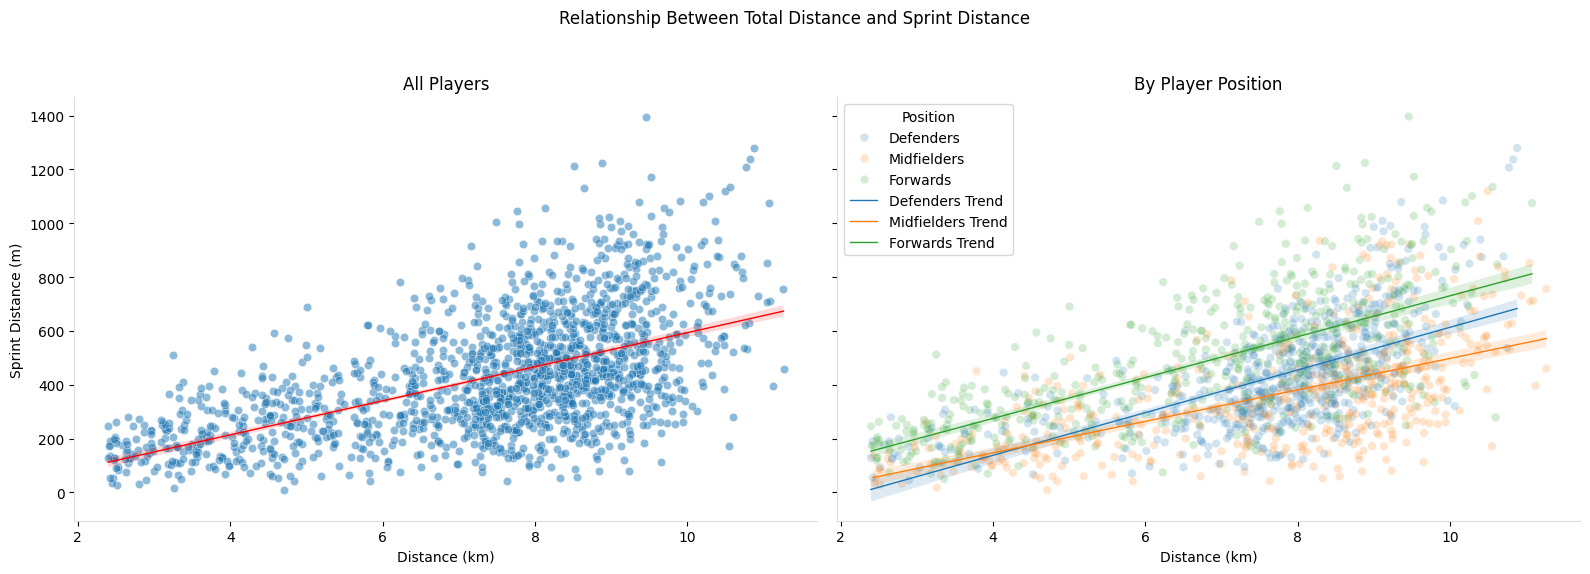

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: All players, no hue
ax1 = axes[0]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', alpha=0.5, ax=ax1)
sns.regplot(data=df, x='distance_km', y='sprint_distance_m', scatter=False, ax=ax1, color='red', line_kws={'linewidth':1})
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Sprint Distance (m)')
ax1.set_title('All Players')
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#E0DCDD')
ax1.spines['bottom'].set_color('#E0DCDD')

# Plot 2: Hue by player position, trend lines for each group
ax2 = axes[1]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', hue='general_position', alpha=0.2, ax=ax2)
for pos in df['general_position'].dropna().unique():
    sns.regplot(
        data=df[df['general_position'] == pos],
        x='distance_km',
        y='sprint_distance_m',
        scatter=False,
        ax=ax2,
        label=f"{pos} Trend",
        line_kws={'linewidth':1}
    )
ax2.set_xlabel('Distance (km)')
ax2.set_ylabel('Sprint Distance (m)')
ax2.set_title('By Player Position')
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#E0DCDD')
ax2.spines['bottom'].set_color('#E0DCDD')
ax2.legend(title='Position')

plt.suptitle('Relationship Between Total Distance and Sprint Distance')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Other Requests

### Pairwise Performance

In [50]:
# Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

clubs = sorted(df['club_for'].unique())
single_matchday_metric = []

for i, club1 in enumerate(clubs):
    for club2 in clubs[i+1:]:
        # Find all matchdays where these two clubs played each other
        matchdays = df[
            ((df['club_for'] == club1) & (df['club_against'] == club2)) |
            ((df['club_for'] == club2) & (df['club_against'] == club1))
        ]['match_day'].unique()
        for md in matchdays:
            # Filter for only this pair and this matchday
            mask = (
                (((df['club_for'] == club1) & (df['club_against'] == club2)) |
                 ((df['club_for'] == club2) & (df['club_against'] == club1))) &
                (df['match_day'] == md)
            )
            relevant_rows = df[mask]
            if not relevant_rows.empty:
                avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
                row = {
                    'Team A': club1,
                    'Team B': club2,
                    'match_day': md
                }
                row.update(avg_metrics.to_dict())
                single_matchday_metric.append(row)

single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
single_matchday_metric_df = single_matchday_metric_df[
    (single_matchday_metric_df['top_speed_kmh'] > 20)
][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] > 8)]
single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] > 300)]
single_matchday_metric_df = single_matchday_metric_df.sort_values(by='player_load', ascending=False).reset_index(drop=True)

style_table_for_docs(single_matchday_metric_df.head(10))

,Team A,Team B,match_day,top_speed_kmh,player_load,distance_km
0,Kampala Queens Fc,Rines Ss Wfc,MD16,27.030969,444.700046,8.958708
1,Kampala Queens Fc,Olila Hs Wfc,MD8,25.963200,427.608538,9.195050
2,Amus College Wfc,She Corporates Fc,MD10,26.104200,423.586870,8.732210
3,Amus College Wfc,Makerere University Wfc,MD8,25.534018,418.517227,8.391909
4,Amus College Wfc,Wakiso Hill Wfc,MD12,26.180927,418.385305,8.241850
5,Olila Hs Wfc,She Maroons Fc,MD12,25.843494,415.442500,8.888224
6,Amus College Wfc,Uganda Martyrs Lubaga Wfc,MD7,26.387109,412.792914,8.489127
7,Makerere University Wfc,Uganda Martyrs Lubaga Wfc,MD22,26.079400,411.464290,8.274180
8,Olila Hs Wfc,Wakiso Hill Wfc,MD11,25.481141,411.198259,8.612788
9,Makerere University Wfc,Rines Ss Wfc,MD18,25.413847,404.534300,8.320912


In [51]:
# Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

clubs = sorted(df['club_for'].unique())
single_matchday_metric = []

for i, club1 in enumerate(clubs):
    for club2 in clubs[i+1:]:
        # Find all matchdays where these two clubs played each other
        matchdays = df[
            ((df['club_for'] == club1) & (df['club_against'] == club2)) |
            ((df['club_for'] == club2) & (df['club_against'] == club1))
        ]['match_day'].unique()
        for md in matchdays:
            # Filter for only this pair and this matchday
            mask = (
                (((df['club_for'] == club1) & (df['club_against'] == club2)) |
                 ((df['club_for'] == club2) & (df['club_against'] == club1))) &
                (df['match_day'] == md)
            )
            relevant_rows = df[mask]
            if not relevant_rows.empty:
                avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
                row = {
                    'Team A': club1,
                    'Team B': club2,
                    'match_day': md
                }
                row.update(avg_metrics.to_dict())
                single_matchday_metric.append(row)

single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
single_matchday_metric_df = single_matchday_metric_df[
    (single_matchday_metric_df['top_speed_kmh'] > 0)
][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] < 9)]
single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] < 400)]
single_matchday_metric_df = single_matchday_metric_df.sort_values(by='distance_km', ascending=True).reset_index(drop=True)

style_table_for_docs(single_matchday_metric_df.head(10))

,Team A,Team B,match_day,top_speed_kmh,player_load,distance_km
0,She Corporates Fc,She Maroons Fc,MD6,25.959127,274.452033,5.578953
1,Kawempe Muslim Lfc,She Corporates Fc,MD22,26.170046,271.764177,5.817169
2,She Maroons Fc,Wakiso Hill Wfc,MD18,25.259109,336.385818,5.867764
3,Rines Ss Wfc,She Maroons Fc,MD19,26.171277,296.060931,6.092869
4,She Corporates Fc,She Maroons Fc,MD17,24.938662,293.460292,6.095869
5,Rines Ss Wfc,She Maroons Fc,MD8,24.765152,312.910986,6.278890
6,Kawempe Muslim Lfc,Wakiso Hill Wfc,MD2,24.823585,341.490669,6.304523
7,Amus College Wfc,Lady Doves Fc,MD2,23.875400,328.484500,6.425540
8,Kampala Queens Fc,Wakiso Hill Wfc,MD1,24.906760,341.887644,6.599260
9,Lady Doves Fc,She Maroons Fc,MD21,26.456771,320.427700,6.626550


In [52]:
# Create a DataFrame showing the averages of all intensity metrics for each team A when they play team B
clubs = sorted(df['club_for'].unique())
avg_intensity_vs_opponent = []

for club1 in clubs:
    for club2 in clubs:
        if club1 == club2:
            continue  # skip self
        mask = (
            ((df['club_for'] == club1) & (df['club_against'] == club2))
        )
        club1_rows = df[mask]
        if not club1_rows.empty:
            avg_metrics = club1_rows[intensity_metrics].mean()
            row = {'Team A': club1, 'Team B': club2}
            row.update(avg_metrics.to_dict())
            avg_intensity_vs_opponent.append(row)

avg_intensity_vs_opponent_df = pd.DataFrame(avg_intensity_vs_opponent)
avg_intensity_vs_opponent_df = avg_intensity_vs_opponent_df.sort_values(by='top_speed_kmh', ascending=False).reset_index(drop=True)
style_table_for_docs(avg_intensity_vs_opponent_df.head(10))

,Team A,Team B,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Kampala Queens Fc,Amus College Wfc,415.512030,27.742610,85.613032,13.109120,67.084010,5.369040,6.704800,3.797518,3.700710
1,Olila Hs Wfc,Amus College Wfc,365.784020,27.577800,86.598609,13.277020,68.818760,4.990500,6.525400,3.451246,3.268102
2,Lady Doves Fc,Kawempe Muslim Lfc,421.761333,27.253533,86.255845,13.408667,65.194533,5.479467,7.408683,3.653323,3.681110
3,Amus College Wfc,Uganda Martyrs Lubaga Wfc,409.786018,27.151473,78.968276,12.371882,64.720173,5.395100,7.282218,3.684974,3.503326
4,Lady Doves Fc,Kampala Queens Fc,389.544592,26.913533,80.042286,12.052783,60.053217,5.453717,6.702867,4.050921,3.927615
5,Kampala Queens Fc,Lady Doves Fc,390.586571,26.894295,81.533027,12.786657,64.246595,5.228762,6.866167,4.239758,4.074719
6,Amus College Wfc,Kampala Queens Fc,368.113585,26.790046,73.380202,11.581435,60.512427,5.298869,6.498404,3.653346,3.519572
7,Kampala Queens Fc,Uganda Martyrs Lubaga Wfc,376.560482,26.767259,74.219508,11.612047,57.444241,5.379653,6.406082,3.709321,3.602537
8,Kampala Queens Fc,Rines Ss Wfc,438.411560,26.678600,97.369112,15.182180,78.252140,5.691960,6.182860,4.955848,4.840399
9,Amus College Wfc,She Maroons Fc,417.653426,26.578726,86.326132,13.399926,68.420047,5.404516,6.767747,3.780742,3.679616


In [53]:
# Create a DataFrame showing the averages of all volume metrics for each team A when they play team B
clubs = sorted(df['club_for'].unique())
avg_volume_vs_opponent = []

for club1 in clubs:
    for club2 in clubs:
        if club1 == club2:
            continue  # skip self
        mask = (
            ((df['club_for'] == club1) & (df['club_against'] == club2))
        )
        club1_rows = df[mask]
        if not club1_rows.empty:
            avg_metrics = club1_rows[volume_metrics].mean()
            row = {'Team A': club1, 'Team B': club2}
            row.update(avg_metrics.to_dict())
            avg_volume_vs_opponent.append(row)

avg_volume_vs_opponent_df = pd.DataFrame(avg_volume_vs_opponent)
avg_volume_vs_opponent_df = avg_volume_vs_opponent_df.sort_values(by='distance_km', ascending=False).reset_index(drop=True)
style_table_for_docs(avg_volume_vs_opponent_df.head(10))

,Team A,Team B,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
0,Olila Hs Wfc,Kampala Queens Fc,9.195050,549.515250,49.625000,880.174487,4.750000,470.125000,452.250000
1,Olila Hs Wfc,She Maroons Fc,9.084929,580.320143,51.142857,923.210871,2.000000,420.428571,401.857143
2,Kampala Queens Fc,Rines Ss Wfc,8.939480,492.476200,48.400000,891.730320,5.000000,455.000000,444.400000
3,Lady Doves Fc,Wakiso Hill Wfc,8.901257,598.118714,46.571429,806.509214,8.142857,363.000000,363.857143
4,Amus College Wfc,She Maroons Fc,8.816042,632.711684,52.631579,867.006989,7.684211,385.842105,375.421053
5,Lady Doves Fc,Kawempe Muslim Lfc,8.773567,667.829833,51.166667,792.127517,8.500000,371.666667,374.500000
6,Amus College Wfc,She Corporates Fc,8.732210,504.489400,44.100000,859.213970,7.500000,407.400000,396.800000
7,Wakiso Hill Wfc,Olila Hs Wfc,8.718350,389.695100,39.900000,805.335490,8.400000,428.100000,411.200000
8,Lady Doves Fc,Rines Ss Wfc,8.672933,491.392667,44.600000,817.192660,5.466667,391.600000,377.533333
9,Olila Hs Wfc,Rines Ss Wfc,8.588771,509.673286,42.857143,837.202971,4.571429,362.428571,354.285714


### Top Performers for each Metric (Individual/ Team/ Pairwise)

In [54]:
# Find top 5 players for each metric in volume_metrics and intensity_metrics
top5_players = []

metrics_to_check = volume_metrics + intensity_metrics
for metric in metrics_to_check:
    # Get top 5 rows for this metric
    top_rows = df.nlargest(5, metric)
    for _, row in top_rows.iterrows():
        top5_players.append({
            'metric': metric,
            'player': row['p_name'],
            'club': row['club_for'],
            'value': row[metric],
            'match day': row['match_day']
        })

top5_players_df = pd.DataFrame(top5_players)
# Optionally, sort for display
top5_players_df = top5_players_df.sort_values(['metric', 'value'], ascending=[True, False]).reset_index(drop=True)
style_table_for_docs(top5_players_df)

,metric,player,club,value,match day
0,acc_counts_per_min,Jackeline Adong,She Maroons Fc,5.982221,MD22
1,acc_counts_per_min,Ndagire Roy,Wakiso Hill Wfc,5.960811,MD1
2,acc_counts_per_min,Jackeline Adong,She Maroons Fc,5.921610,MD20
3,acc_counts_per_min,Mary Lotyang Elgonda,Olila Hs Wfc,5.834166,MD8
4,acc_counts_per_min,Jackeline Adong,She Maroons Fc,5.830914,MD7
5,dec_counts_per_min,Jackeline Adong,She Maroons Fc,5.971762,MD22
6,dec_counts_per_min,Jackeline Adong,She Maroons Fc,5.826271,MD20
7,dec_counts_per_min,Jackeline Adong,She Maroons Fc,5.759180,MD7
8,dec_counts_per_min,Ndagire Roy,Wakiso Hill Wfc,5.744242,MD1
9,dec_counts_per_min,Jackeline Adong,She Maroons Fc,5.741472,MD19


### Best Performers in each position

In [55]:
# Combine metrics into one list
all_metrics = volume_metrics + intensity_metrics

# Store top 5 players per metric and position
top5_players_by_position = []

for metric in all_metrics:
    for position in df['general_position'].dropna().unique():
        # Get top 5 players for this metric and position
        top_rows = df[df['general_position'] == position].nlargest(5, metric)
        
        for _, row in top_rows.iterrows():
            top5_players_by_position.append({
                'metric': metric,
                'player': row['p_name'],
                'club': row['club_for'],
                'value': row[metric],
                'match day': row['match_day'],
                'position': position
            })

# Convert to DataFrame
top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# Sort by metric name (alphabetically) and then value (descending)
top5_players_by_position_df = top5_players_by_position_df.sort_values(
    ['metric', 'value'], ascending=[True, False]
).reset_index(drop=True)

# Apply your styling function
style_table_for_docs(top5_players_by_position_df)



,metric,player,club,value,match day,position
0,acc_counts_per_min,Jackeline Adong,She Maroons Fc,5.982221,MD22,Midfielders
1,acc_counts_per_min,Ndagire Roy,Wakiso Hill Wfc,5.960811,MD1,Forwards
2,acc_counts_per_min,Jackeline Adong,She Maroons Fc,5.921610,MD20,Midfielders
3,acc_counts_per_min,Mary Lotyang Elgonda,Olila Hs Wfc,5.834166,MD8,Midfielders
4,acc_counts_per_min,Jackeline Adong,She Maroons Fc,5.830914,MD7,Midfielders
5,acc_counts_per_min,Esther Nangendo,Kawempe Muslim Lfc,5.818432,MD20,Midfielders
6,acc_counts_per_min,Nabulime Jamilah,Kampala Queens Fc,5.707025,MD16,Defenders
7,acc_counts_per_min,Dorcus Nabuufu,She Maroons Fc,5.669804,MD3,Defenders
8,acc_counts_per_min,Daphine Apio Doreen,Olila Hs Wfc,5.599455,MD7,Forwards
9,acc_counts_per_min,Emilly Nabuzale,Amus College Wfc,5.565844,MD9,Defenders


In [56]:
# Combine metrics into one list
all_metrics = volume_metrics + intensity_metrics

# Group by player and position, then average all metrics
avg_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].mean().reset_index()

# Store top 5 players per metric and position
top5_players_by_position = []

for metric in all_metrics:
    for position in avg_df['general_position'].dropna().unique():
        # Get top 5 players for this metric and position
        top_rows = avg_df[avg_df['general_position'] == position].nlargest(5, metric)
        
        for _, row in top_rows.iterrows():
            top5_players_by_position.append({
                'metric': metric,
                'player': row['p_name'],
                'club': row['club_for'],
                'value': row[metric],
                'position': position
            })

# Convert to DataFrame
top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# Sort for display: alphabetically by metric, descending by value
top5_players_by_position_df = top5_players_by_position_df.sort_values(
    ['metric', 'value'], ascending=[True, False]
).reset_index(drop=True)

# Display nicely (assuming this is your custom function)
style_table_for_docs(top5_players_by_position_df)


,metric,player,club,value,position
0,acc_counts_per_min,Harriet Adubango,Olila Hs Wfc,5.160373,Defenders
1,acc_counts_per_min,Lydia Nyandera,Lady Doves Fc,5.005905,Midfielders
2,acc_counts_per_min,Immaculate Nakanjako,Uganda Martyrs Lubaga Wfc,4.897306,Midfielders
3,acc_counts_per_min,Marion Amangat,Olila Hs Wfc,4.879178,Defenders
4,acc_counts_per_min,Catherine Namataka,Amus College Wfc,4.793500,Defenders
5,acc_counts_per_min,Jackeline Adong,She Maroons Fc,4.782402,Midfielders
6,acc_counts_per_min,Resy Kobusobozi,Lady Doves Fc,4.763436,Midfielders
7,acc_counts_per_min,Nalugya Shamirah,Kampala Queens Fc,4.719203,Midfielders
8,acc_counts_per_min,Namusoke Esther,Kampala Queens Fc,4.688936,Defenders
9,acc_counts_per_min,Sharon Acen,Olila Hs Wfc,4.667747,Defenders


In [57]:
# Custom position sorting order
position_order = ['Defenders', 'Midfielders', 'Forwards']

# Step 1: Count appearances (unique match days)
appearances_df = df.groupby(['p_name', 'general_position', 'club_for'])['match_day'].nunique().reset_index()
appearances_df = appearances_df.rename(columns={'match_day': 'appearances'})

# Step 2: Calculate mean and std for metrics
metrics_stats_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].agg(['mean', 'std']).reset_index()

# Step 3: Fix column names: flatten multi-index columns
metrics_stats_df.columns = [
    f"{metric}_{stat}" if stat else metric
    for metric, stat in metrics_stats_df.columns.to_flat_index()
]

# Step 4: Merge with appearances
merged_df = metrics_stats_df.merge(
    appearances_df,
    on=['p_name', 'general_position', 'club_for']
)

# Step 5: Only include players with at least 3 appearances
filtered_df = merged_df[merged_df['appearances'] >= 15]

# Step 6: Extract top 5 players for each metric and position
top5_players_by_position = []

for metric in all_metrics:
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'

    for position in position_order:
        group = filtered_df[filtered_df['general_position'] == position]

        # Skip if metric column is missing
        if mean_col not in group.columns:
            continue

        top_rows = group.nlargest(5, mean_col)

        for _, row in top_rows.iterrows():
            top5_players_by_position.append({
                'metric': metric,
                'player': row['p_name'],
                'club': row['club_for'],
                'mean_value': row[mean_col],
                'std_dev': row[std_col],
                'appearances': row['appearances'],
                'position': position
            })

# Step 7: Create and sort final DataFrame
top5_df = pd.DataFrame(top5_players_by_position)

# Sort positions using custom category
top5_df['position'] = pd.Categorical(
    top5_df['position'], categories=position_order, ordered=True
)

# Sort by metric → position → mean value
top5_df = top5_df.sort_values(['metric', 'position', 'mean_value'], ascending=[True, True, False]).reset_index(drop=True)

# Show results
style_table_for_docs(top5_df.round(2))


,metric,player,club,mean_value,std_dev,appearances,position
0,acc_counts_per_min,Catherine Namataka,Amus College Wfc,4.790000,0.410000,15,Defenders
1,acc_counts_per_min,Dorcus Nabuufu,She Maroons Fc,4.600000,0.500000,17,Defenders
2,acc_counts_per_min,Hilati Kaudha,Rines Ss Wfc,4.150000,0.540000,17,Defenders
3,acc_counts_per_min,Gloria Namugerwa,Uganda Martyrs Lubaga Wfc,3.900000,0.370000,17,Defenders
4,acc_counts_per_min,Adrine Birungi,Rines Ss Wfc,3.810000,0.640000,16,Defenders
5,acc_counts_per_min,Immaculate Nakanjako,Uganda Martyrs Lubaga Wfc,4.900000,0.550000,15,Midfielders
6,acc_counts_per_min,Agnes Nabukenya,Kawempe Muslim Lfc,4.490000,0.440000,17,Midfielders
7,acc_counts_per_min,Tezikya Anitah,Wakiso Hill Wfc,4.460000,1.040000,15,Midfielders
8,acc_counts_per_min,Yasmeen Nalukwago,Rines Ss Wfc,3.690000,0.680000,16,Midfielders
9,acc_counts_per_min,Krusum Namutebi,Kawempe Muslim Lfc,3.200000,0.840000,16,Midfielders


## Speed Zones

### Distance in Speed Zones

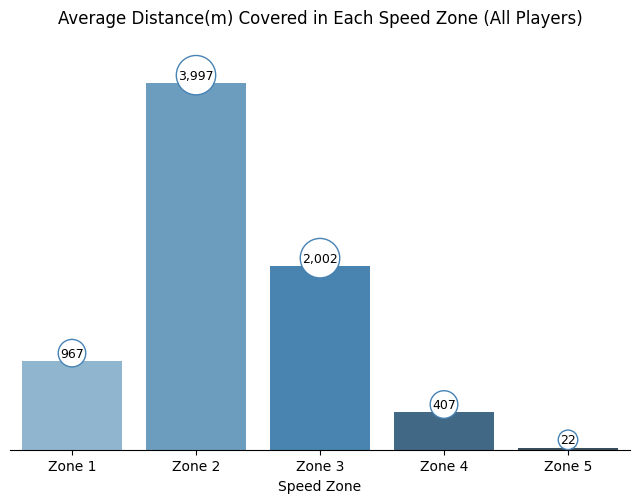

In [58]:
# List of speed zone columns
speed_zone_cols = [
    'distance_in_speed_zone_1_km',
    'distance_in_speed_zone_2_km',
    'distance_in_speed_zone_3_km',
    'distance_in_speed_zone_4_km',
    'distance_in_speed_zone_5_km'
]

# Compute average distance for each speed zone
avg_speed_zone_dist = df[speed_zone_cols].mean()

# Prepare labels (replace _ with space, add zone number)
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

plt.figure(figsize=(8, 5))


# Create barplot
# plt.figure(figsize=(12,6))
sns.barplot(x=zone_labels,hue=zone_labels, y=avg_speed_zone_dist.values, palette='Blues_d',legend=False)

# Title, subtitle, and axis labels
# plt.ylabel("Average Distance (m)")
plt.xlabel("Speed Zone")
plt.title("Average Distance(m) Covered in Each Speed Zone (All Players)", pad=30)

ax= plt.gca()

# Gridlines for y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate values inside bars
for i, v in enumerate(avg_speed_zone_dist):
    # Convert km to m and format with comma

    ax.annotate(
        f"{int(round(v),):,}",
        xy=(i, v),
        xytext=(0, 1),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        bbox=dict(boxstyle="circle,pad=0.15", edgecolor='#4682B4', facecolor='white', linewidth=1)
    )

#remove yaxis ticklabels
ax.set_yticklabels([])
ax.set_yticks([])

plt.show()


C:\Users\Travail\AppData\Local\Temp\ipykernel_17980\2362410231.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


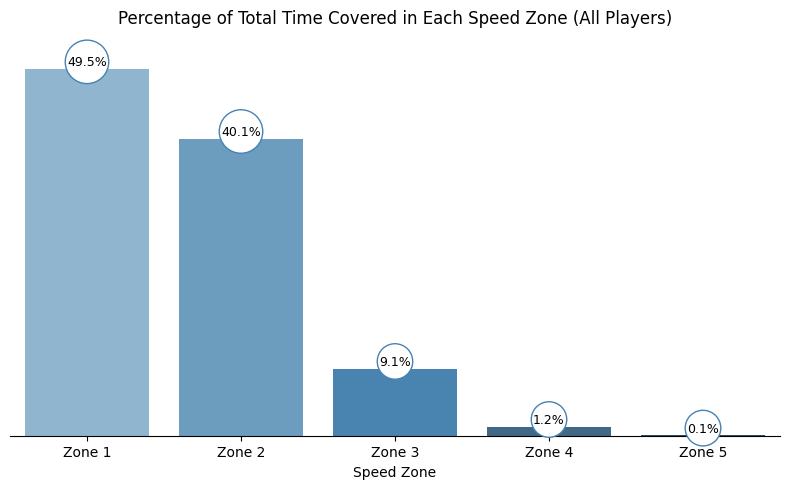

In [59]:

# List of speed zone columns 
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Compute average time (secs) for each speed zone
avg_time_secs = df[speed_zone_cols].mean()

# Total average time across all zones
total_time = avg_time_secs.sum()

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=zone_labels,
    y=avg_time_secs.values / 60,      # convert to minutes on the y-axis
    palette='Blues_d',
    dodge=False
)

# Title and axis labels
ax.set_xlabel("Speed Zone")
ax.set_title("Percentage of Total Time Covered in Each Speed Zone (All Players)", pad=20)

# Gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
sns.despine(ax=ax, top=True, right=True, left=True)

# Annotate with percentages
for i, secs in enumerate(avg_time_secs):
    pct = (secs / total_time) * 100
    ax.text(
        i, 
        (secs / 60) + 0.1,           # place label just above the bar (in minutes)
        f"{pct:.1f}%",               
        ha='center', 
        va='bottom', 
        fontsize=9,
        bbox=dict(boxstyle="circle,pad=0.15", edgecolor='#4682B4', facecolor='white', linewidth=1)
    )

# Optionally remove y-ticks if you only want to show percentage
ax.set_yticks([])

plt.tight_layout()
plt.show()


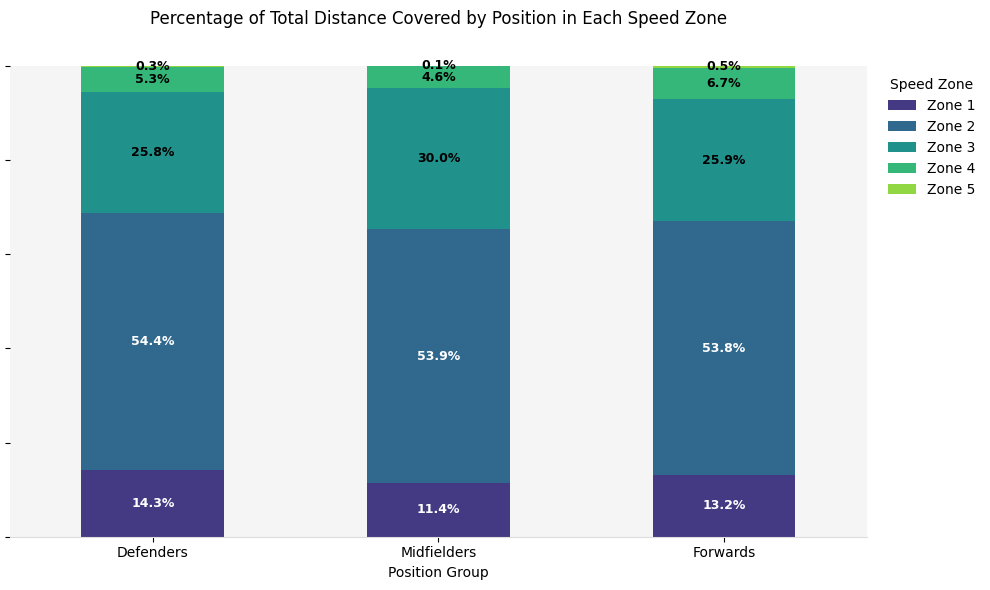

In [60]:
# Prepare data for 100% stacked bar plot: percentage distance in each speed zone grouped by position
speed_zone_cols = [
    'distance_in_speed_zone_1_km',
    'distance_in_speed_zone_2_km',
    'distance_in_speed_zone_3_km',
    'distance_in_speed_zone_4_km',
    'distance_in_speed_zone_5_km'
]

# Group by position and sum distances (in km)
zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# Reorder positions if desired
position_order = ['Defenders', 'Midfielders', 'Forwards']
zone_by_position = zone_by_position.reindex(position_order)

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
zone_by_position.columns = zone_labels

# Convert to percentages row-wise
zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# Plot
ax = zone_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette('viridis', n_colors=len(zone_labels))
)

# Annotate values inside each bar segment (as percentages, one decimal)
for i, pos in enumerate(zone_pct.index):
    cumulative = 0
    for j, zone in enumerate(zone_labels):
        value = zone_pct.loc[pos, zone]
        height = value
        y = cumulative + height / 2
        if value > 0.05:  # Only annotate if segment is large enough
            ax.text(
                i, y, f"{value:.1f}%",
                ha='center', va='center', fontsize=9, color='black' if j > 1 else 'white', fontweight='bold'
            )
        cumulative += height

plt.xlabel('Position Group')
plt.title('Percentage of Total Distance Covered by Position in Each Speed Zone',pad=30)
plt.xticks(rotation=0)
plt.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
# Remove top, left, and right spines
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#E0DCDD')
ax.set_facecolor('#F5F5F5')

# Remove yaxis ticklabels and set y-axis to 0-100%
ax.set_yticklabels([])
ax.set_yticks([])

ax.set_yticks(range(0, 101, 20))
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

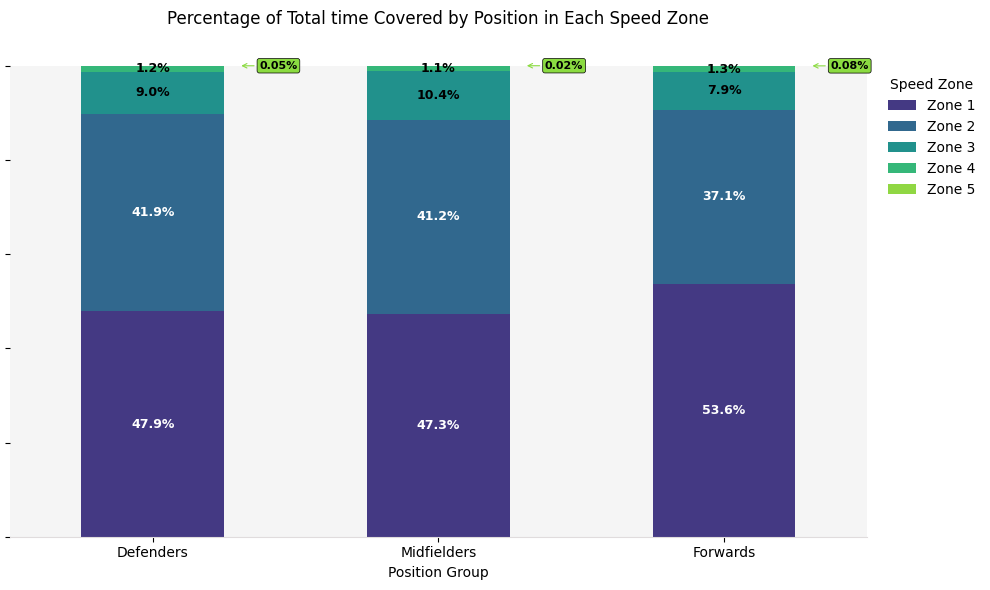

In [61]:
from matplotlib.patches import Patch

# Prepare data for 100% stacked bar plot: percentage time in each speed zone grouped by position
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Group by position and sum times (in secs)
zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# Reorder positions if desired
position_order = ['Defenders', 'Midfielders', 'Forwards']
zone_by_position = zone_by_position.reindex(position_order)


# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
zone_by_position.columns = zone_labels

# Convert to percentages row-wise
zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# Plot
ax = zone_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette('viridis', n_colors=len(zone_labels))
)

# Annotate values inside each bar segment (as percentages, one decimal)
for i, pos in enumerate(zone_pct.index):
    cumulative = 0
    for j, zone in enumerate(zone_labels):
        value = zone_pct.loc[pos, zone]
        height = value
        y = cumulative + height / 2
        if value > 0.5:  # Only annotate if segment is large enough
            ax.text(
            i, y, f"{value:.1f}%",
            ha='center', va='center', fontsize=9, color='black' if j > 1 else 'white', fontweight='bold'
            )
        else:
            # Place a callout to the right side of the bar for small segments in Zone 5
            if zone == "Zone 5":
                ax.annotate(
                    f"{value:.2f}%",
                    xy=(i + 0.3, cumulative + height / 2),  # right side of the bar
                    xytext=(15, 0),  # offset to the right
                    textcoords='offset points',
                    ha='left',
                    va='center',
                    fontsize=8,
                    fontweight='bold',
                    color='black',
                    # Use a rounded rectangle for the callout box
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="#8BDB41", linewidth=0.5),
                    arrowprops=dict(arrowstyle='->', color='#8BDB41', lw=0.8)
                )
        cumulative += height

plt.xlabel('Position Group')
plt.title('Percentage of Total time Covered by Position in Each Speed Zone',pad=30)
plt.xticks(rotation=0)
plt.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
# Remove top, left, and right spines
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#E0DCDD')
ax.set_facecolor('#F5F5F5')

# Remove yaxis ticklabels and set y-axis to 0-100%
ax.set_yticklabels([])
ax.set_yticks([])

ax.set_yticks(range(0, 101, 20))
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()